# Ângulos na Circunferência

**Módulo:** 04 – Geometria Plana

**Pré-requisitos:** [`0403a_angulos.ipynb`](0403a_angulos.ipynb) (medida em graus, congruência, bissetriz, ângulos suplementares e de uma volta), [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (soma dos ângulos internos e o **teorema do ângulo externo**, a ferramenta central das demonstrações), [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) (no triângulo isósceles, os ângulos da base são congruentes), [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) (perpendicular, ângulo reto, lugar geométrico) e [`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb) (corda, arco, diâmetro, a **tangente perpendicular ao raio**, e a diferença entre circunscritível e inscritível).

**Objetivos de aprendizagem:** ao final você será capaz de...
- Medir um arco em graus e comparar arcos (congruência, adição, desigualdade), distinguindo a **medida angular** de um arco do seu **comprimento**.
- Relacionar o **ângulo central** com o arco que ele determina.
- Enunciar e aplicar o **teorema do ângulo inscrito** (metade do arco) e suas consequências: mesmo arco ⇒ mesmo ângulo, triângulo retângulo inscrito numa semicircunferência e **quadrilátero inscritível** (ângulos opostos suplementares).
- Calcular o **ângulo de segmento** (tangente + corda) e os **ângulos excêntricos** (interior e exterior) a partir dos arcos.

**Tempo estimado:** 90 a 105 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/04_geometria_plana/0413a_angulos_na_circunferencia.ipynb)

## O fotógrafo e o gol

Um fotógrafo quer enquadrar o **gol inteiro**, de uma trave à outra, com uma lente que abre exatamente **40°**. Se ele ficar perto demais, o gol não cabe na foto; longe demais, o gol fica pequeno e sobra espaço. A pergunta é: **de quais pontos do campo** o gol aparece sob um ângulo de exatamente 40°?

Uma primeira ideia é andar em linha reta, de frente para o gol. Ao se afastar, o ângulo diminui; ao se aproximar, aumenta. Então existe **um** ponto certo nessa reta. Mas a pergunta era sobre **todos** os pontos do campo. Existe alguma curva em que o ângulo de visão do gol fica **sempre igual**, por mais que o fotógrafo ande?

Pense um pouco: que formato você acha que essa curva tem?

Execute a célula abaixo (ela carrega as ferramentas do notebook) e depois a do widget, para pôr o fotógrafo para andar.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc, Circle, Polygon, Wedge

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Ferramentas de desenho e de medida dos notebooks anteriores (0407a, 0410a, 0411a e 0412a)

def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice`
    formado pelas semirretas que passam por P e por Q (resultado entre 0° e 180°)."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def cruzamento(P, inclinacao_1: float, Q, inclinacao_2: float):
    """Ponto em que a reta que passa por P (com a inclinação `inclinacao_1`, em graus) cruza a reta
    que passa por Q (com a inclinação `inclinacao_2`). Devolve None se as duas retas tiverem a mesma
    direção, porque aí elas não se cruzam num ponto só.

    Por trás, é um sistema linear 2×2 (módulo 03): P + t·u = Q + k·v, com incógnitas t e k.
    """
    matriz = np.column_stack([direcao(inclinacao_1), -direcao(inclinacao_2)])
    if abs(np.linalg.det(matriz)) < 1e-12:
        return None
    t, _ = np.linalg.solve(matriz, np.subtract(Q, P))
    return np.array(P, dtype=float) + t * direcao(inclinacao_1)


def inclinacao_da_perpendicular(inclinacao_r: float) -> float:
    """Inclinação da perpendicular a uma reta de inclinação `inclinacao_r`: girar 90° (a menos de 180°)."""
    return (inclinacao_r + 90) % 180


def projecao_ortogonal(P, ponto_r, inclinacao_r: float) -> np.ndarray:
    """Projeção ortogonal P' de P sobre a reta r (que passa por `ponto_r`, com a inclinação dada):
    o pé da perpendicular a r traçada por P (0407a)."""
    return cruzamento(P, inclinacao_da_perpendicular(inclinacao_r), ponto_r, inclinacao_r)


def distancia_ponto_reta(P, ponto_r, inclinacao_r: float) -> float:
    """Distância de P à reta r: a medida de PP', com P' a projeção ortogonal de P sobre r (0407a)."""
    return math.dist(P, projecao_ortogonal(P, ponto_r, inclinacao_r))


def ponto_medio(P, Q) -> np.ndarray:
    """Ponto médio do segmento PQ: a média das coordenadas (0402a)."""
    return (np.asarray(P, dtype=float) + np.asarray(Q, dtype=float)) / 2


def mediatriz(A, B) -> tuple[np.ndarray, float]:
    """A mediatriz de AB, descrita como toda reta destes notebooks: um ponto (o ponto médio M) e a
    inclinação (0407a)."""
    return ponto_medio(A, B), inclinacao_da_perpendicular(direcao_de(A, B))


def circuncentro(A, B, C) -> np.ndarray:
    """Circuncentro do triângulo ABC: o cruzamento das mediatrizes de AB e de BC (0410a)."""
    return cruzamento(*mediatriz(A, B), *mediatriz(B, C))


def iguais(x: float, y: float) -> bool:
    """Compara duas medidas com uma tolerância pequena (as contas com float têm arredondamentos)."""
    return math.isclose(x, y, rel_tol=1e-9, abs_tol=1e-6)


def desenhar_ponto(ax, p, nome: str = "", cor: str = COR_AVISO, deslocamento=(0.12, 0.15),
                   tamanho_fonte: int = 13) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=7, zorder=6)
    if nome:
        ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=tamanho_fonte,
                fontweight="bold", zorder=7)


def desenhar_reta(ax, P, Q, cor: str = COR_SECUNDARIA, estilo: str = "-", largura: float = 2.0,
                  alpha: float = 0.9) -> None:
    """Desenha a reta inteira que passa por P e por Q (até a borda do gráfico)."""
    ax.axline(tuple(np.asarray(P, dtype=float)), tuple(np.asarray(Q, dtype=float)), color=cor,
              linestyle=estilo, lw=largura, alpha=alpha, zorder=2)


def desenhar_setor(ax, vertice, inicio: float, abertura: float, raio: float = 0.5, cor: str = COR_PONTO,
                   rotulo: str | None = None, marcar_reto: bool = True, raio_rotulo: float | None = None,
                   tamanho_fonte: int = 11) -> None:
    """Pinta o ângulo com vértice em `vertice` que começa na direção `inicio` e gira `abertura`
    graus no sentido anti-horário. O ângulo reto ganha o quadradinho no lugar do arco."""
    v = np.array(vertice, dtype=float)
    if marcar_reto and math.isclose(abertura, 90, abs_tol=1e-6):
        lado = 0.6 * raio
        canto = [v, v + lado * direcao(inicio), v + lado * (direcao(inicio) + direcao(inicio + 90)),
                 v + lado * direcao(inicio + 90)]
        ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2))
    else:
        ax.add_patch(Wedge(v, raio, inicio, inicio + abertura, facecolor=cor, alpha=0.3, edgecolor="none"))
        ax.add_patch(Arc(v, 2 * raio, 2 * raio, theta1=inicio, theta2=inicio + abertura, color=cor, lw=2))
    if rotulo:
        distancia_rotulo = 1.6 * raio if raio_rotulo is None else raio_rotulo
        posicao = v + distancia_rotulo * direcao(inicio + abertura / 2)
        ax.text(*posicao, rotulo, color=cor, fontsize=tamanho_fonte, ha="center", va="center", fontweight="bold")


def desenhar_arco(ax, vertice, p, q, **opcoes) -> None:
    """Marca o ângulo de vértice `vertice` formado pelas semirretas que passam por p e por q
    (sempre a abertura menor, entre 0° e 180°). Aceita as mesmas opções de `desenhar_setor`."""
    inicio = direcao_de(vertice, p) % 360
    abertura = (direcao_de(vertice, q) - inicio) % 360
    if abertura > 180:
        inicio, abertura = direcao_de(vertice, q) % 360, 360 - abertura
    desenhar_setor(ax, vertice, inicio, abertura, **opcoes)


def marcar_angulo_reto(ax, vertice, p, q, tamanho: float = 0.3, cor: str = COR_DESTAQUE) -> None:
    """Desenha o quadradinho de ângulo reto no `vertice`, entre as semirretas que passam por p e por q."""
    v = np.array(vertice, dtype=float)
    u = np.subtract(p, v) / np.linalg.norm(np.subtract(p, v))
    w = np.subtract(q, v) / np.linalg.norm(np.subtract(q, v))
    canto = [v, v + tamanho * u, v + tamanho * (u + w), v + tamanho * w]
    ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2, zorder=4))


def marcar_congruentes(ax, P, Q, tracos: int = 1, cor: str = NORD_TEXTO, tamanho: float = 0.16) -> None:
    """Tracinhos no meio do segmento PQ: a marca de segmentos congruentes (0402a)."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    u = (Q - P) / np.linalg.norm(Q - P)
    normal = np.array([-u[1], u[0]])
    meio = (P + Q) / 2
    for k in range(tracos):
        centro_traco = meio + (k - (tracos - 1) / 2) * 0.12 * u
        ax.plot(*zip(centro_traco - tamanho * normal, centro_traco + tamanho * normal), color=cor, lw=2,
                zorder=6)


def rotular_fora(ax, P, texto: str, centro, cor: str = NORD_TEXTO, distancia: float = 0.35,
                 tamanho: int = 12) -> None:
    """Escreve `texto` perto do ponto P, afastado do `centro` (para não ficar em cima da figura)."""
    P = np.asarray(P, dtype=float)
    afastar = P - np.asarray(centro, dtype=float)
    afastar = afastar / np.linalg.norm(afastar) if np.linalg.norm(afastar) > 0 else np.array([0.0, 1.0])
    ax.text(*(P + distancia * afastar), texto, color=cor, fontsize=tamanho, fontweight="bold",
            ha="center", va="center", zorder=7)


def escrever_checklist(ax, itens, titulo: str = "") -> None:
    """Painel de texto com uma linha por item (texto, ok): ✓ verde quando vale, ✗ vermelho quando não (0410a)."""
    ax.set_facecolor(NORD_FUNDO)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    if titulo:
        ax.text(0.0, 0.97, titulo, color=NORD_TEXTO, fontsize=12, fontweight="bold", va="top")
    passo = min(0.13, 0.85 / max(len(itens), 1))
    for k, (texto, ok) in enumerate(itens):
        ax.text(0.0, 0.84 - k * passo, f"{'✓' if ok else '✗'}  {texto}", color=COR_DESTAQUE if ok else COR_ALERTA,
                fontsize=11, va="top")


# Ferramentas da circunferência (0412a)
def ponto_na_circunferencia(O, r: float, angulo_graus: float) -> np.ndarray:
    """O ponto da circunferência de centro O e raio r que está na direção `angulo_graus`, vista do centro:
    é só andar r a partir de O nessa direção."""
    return np.asarray(O, dtype=float) + r * direcao(angulo_graus)


def desenhar_circunferencia(ax, O, r: float, cor: str = COR_PONTO, estilo: str = "-",
                            largura: float = 2.5, preencher: bool = False, opacidade: float = 0.15) -> None:
    """Desenha a circunferência de centro O e raio r (a linha). Com `preencher=True`, pinta também a
    região interna: o círculo."""
    O = tuple(np.asarray(O, dtype=float))
    if preencher:
        ax.add_patch(Circle(O, r, facecolor=cor, alpha=opacidade, edgecolor="none", zorder=1))
    ax.add_patch(Circle(O, r, fill=False, edgecolor=cor, lw=largura, linestyle=estilo, zorder=3))


def posicao_reta_circunferencia(O, r: float, A, B) -> str:
    """Posição da reta AB em relação à circunferência λ(O, r): 'exterior', 'tangente' ou 'secante'.
    Compara a distância d do centro à reta (0407a) com o raio."""
    d = distancia_ponto_reta(O, A, direcao_de(A, B))
    if iguais(d, r):
        return "tangente"
    return "secante" if d < r else "exterior"


def intersecao_reta_circunferencia(O, r: float, A, B) -> list[np.ndarray]:
    """Pontos comuns da reta AB com a circunferência λ(O, r): nenhum, um ou dois (0412a).

    A partir do pé H da perpendicular baixada de O à reta, andamos "meia corda" para cada lado, com
    meia corda = √(r² − d²) (Pitágoras, 📌 Triângulos Retângulos; aqui só serve para desenhar).
    """
    inclinacao = direcao_de(A, B)
    H = projecao_ortogonal(O, A, inclinacao)
    posicao = posicao_reta_circunferencia(O, r, A, B)
    if posicao == "exterior":
        return []
    if posicao == "tangente":
        return [H]
    meia_corda = math.sqrt(r**2 - math.dist(O, H) ** 2)
    return [H - meia_corda * direcao(inclinacao), H + meia_corda * direcao(inclinacao)]


# Ferramentas novas deste notebook: UMA cor fixa para cada tipo de ângulo, em todas as figuras
COR_CIRCUNFERENCIA = COR_PONTO  # a linha da circunferência
COR_CENTRO = NORD_TEXTO  # o centro
COR_ARCO = COR_AVISO  # o arco "enxergado" pelo ângulo
COR_ARCO_2 = COR_SECUNDARIA  # o outro arco (o arco maior, ou o segundo arco dos excêntricos)
COR_CENTRAL = COR_DESTAQUE  # ângulo central (e os raios que o formam)
COR_INSCRITO = COR_EXTRA  # ângulo inscrito (e as cordas que o formam)
COR_SEGMENTO = "#D08770"  # ângulo de segmento (tangente + corda)
COR_EXCENTRICO = COR_ALERTA  # ângulos excêntricos (interior e exterior)
COR_TANGENTE = NORD_TEXTO_SEC  # retas tangentes


def medida_arco(inicio: float, fim: float) -> float:
    """Medida, em graus, do arco percorrido no sentido anti-horário da direção `inicio` até a direção `fim`
    (um número entre 0° e 360°)."""
    return (fim - inicio) % 360


def desenhar_arco_da_circunferencia(ax, O, r: float, inicio: float, fim: float, cor: str = COR_ARCO,
                                    largura: float = 5.0) -> None:
    """Destaca o arco da circunferência (O, r) que vai da direção `inicio` até a direção `fim`, em graus,
    no sentido anti-horário."""
    ax.add_patch(Arc(tuple(np.asarray(O, dtype=float)), 2 * r, 2 * r, theta1=inicio,
                     theta2=inicio + medida_arco(inicio, fim), color=cor, lw=largura, zorder=4))


def desenhar_arco_menor(ax, O, r: float, P, Q, cor: str = COR_ARCO, largura: float = 5.0) -> None:
    """Destaca o MENOR dos dois arcos de extremidades P e Q."""
    p, q = direcao_de(O, P), direcao_de(O, Q)
    if medida_arco(p, q) <= 180:
        desenhar_arco_da_circunferencia(ax, O, r, p, q, cor, largura)
    else:
        desenhar_arco_da_circunferencia(ax, O, r, q, p, cor, largura)


def arco_enxergado(O, vertice, A, B) -> float:
    """Medida do arco AB que NÃO contém o `vertice` (um ponto da circunferência): é o arco que fica
    "dentro" do ângulo AV̂B, o arco que o ângulo enxerga."""
    a, b, v = (direcao_de(O, X) for X in (A, B, vertice))
    anti_horario = medida_arco(a, b)
    if medida_arco(a, v) < anti_horario:  # o vértice está no arco anti-horário de A até B: o outro arco
        return 360 - anti_horario
    return anti_horario


def desenhar_arco_enxergado(ax, O, r: float, vertice, A, B, cor: str = COR_ARCO, largura: float = 5.0) -> None:
    """Destaca o arco AB que NÃO contém o `vertice`."""
    a, b, v = (direcao_de(O, X) for X in (A, B, vertice))
    if medida_arco(a, v) < medida_arco(a, b):
        desenhar_arco_da_circunferencia(ax, O, r, b, a, cor, largura)
    else:
        desenhar_arco_da_circunferencia(ax, O, r, a, b, cor, largura)

🕹️ **Widget interativo:** o segmento branco é o gol (7,32 m, a largura oficial), e as linhas roxas ligam o fotógrafo às duas traves. O botão `caminho` escolhe por onde ele anda: em **linha reta**, de frente para o gol, ou pela **curva** tracejada azul. O slider `posição` faz ele andar. À direita, o gráfico mostra o ângulo de visão em cada posição, para os dois caminhos. Compare: em qual dos dois o ângulo fica constante?

In [ ]:
GOL_A = np.array([-3.66, 0.0])  # trave esquerda (o gol oficial tem 7,32 m de largura)
GOL_B = np.array([3.66, 0.0])  # trave direita
ANGULO_VISAO = 40

# A curva em que o gol é visto sob 40°. Por enquanto, a construção é uma "caixa-preta": o porquê deste
# centro e deste raio aparece na seção 3 (o arco capaz). tan e sin vêm da Trigonometria (módulo 05);
# aqui só servem para construir a figura.
CENTRO_CURVA = np.array([0.0, GOL_B[0] / math.tan(math.radians(ANGULO_VISAO))])
RAIO_CURVA = GOL_B[0] / math.sin(math.radians(ANGULO_VISAO))
INICIO_CURVA = direcao_de(CENTRO_CURVA, GOL_B)  # a curva começa numa trave...
FIM_CURVA = direcao_de(CENTRO_CURVA, GOL_A) % 360  # ...e termina na outra
TOPO_CURVA = CENTRO_CURVA[1] + RAIO_CURVA  # o ponto mais alto da curva, de frente para o gol


def posicao_do_fotografo(caminho: str, posicao: int) -> np.ndarray:
    """Onde o fotógrafo está, para `posicao` de 0 a 100, andando em linha reta ou pela curva."""
    if caminho == "reta":
        return np.array([0.0, TOPO_CURVA * (0.2 + 1.6 * posicao / 100)])
    angulo = INICIO_CURVA + 5 + (FIM_CURVA - INICIO_CURVA - 10) * posicao / 100
    return ponto_na_circunferencia(CENTRO_CURVA, RAIO_CURVA, angulo)


def explorar_fotografo(caminho: str, posicao: int) -> None:
    P = posicao_do_fotografo(caminho, posicao)
    angulo = medir_angulo(P, GOL_A, GOL_B)
    fig, (ax, ax_graf) = plt.subplots(1, 2, figsize=(14, 6.6), gridspec_kw={"width_ratios": [1, 1.1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-9.5, -1.5), (9.5, 19)], margem=0)
    ax.axhline(0, color=NORD_TEXTO_SEC, lw=1.2, alpha=0.6)  # a linha de fundo do campo
    ax.plot(*zip(GOL_A, GOL_B), color=NORD_TEXTO, lw=6, solid_capstyle="butt", zorder=5)
    for trave in (GOL_A, GOL_B):
        ax.plot(*trave, "s", color=COR_AVISO, markersize=10, zorder=6)
    ax.text(0, -0.9, "gol", color=NORD_TEXTO, fontsize=12, fontweight="bold", ha="center")
    # Os dois caminhos possíveis (o escolhido fica mais forte)
    angulos_curva = np.linspace(INICIO_CURVA, FIM_CURVA, 200)
    curva = np.array([ponto_na_circunferencia(CENTRO_CURVA, RAIO_CURVA, a) for a in angulos_curva])
    ax.plot(curva[:, 0], curva[:, 1], color=COR_CIRCUNFERENCIA, lw=2.2, linestyle="--",
            alpha=0.95 if caminho == "curva" else 0.3, zorder=2)
    ax.plot([0, 0], [0.2 * TOPO_CURVA, 1.8 * TOPO_CURVA], color=NORD_TEXTO_SEC, lw=2, linestyle=":",
            alpha=0.95 if caminho == "reta" else 0.3, zorder=2)
    # O ângulo de visão
    for trave in (GOL_A, GOL_B):
        ax.plot(*zip(P, trave), color=COR_INSCRITO, lw=2.2, zorder=4)
    desenhar_arco(ax, P, GOL_A, GOL_B, raio=1.3, cor=COR_INSCRITO, rotulo=f"{angulo:.1f}°", raio_rotulo=2.4,
                  tamanho_fonte=12)
    ax.plot(*P, "o", color=NORD_TEXTO, markersize=14, markeredgecolor=COR_INSCRITO, markeredgewidth=2.5, zorder=7)
    ax.text(P[0] + 0.6, P[1] + 0.4, "fotógrafo", color=NORD_TEXTO, fontsize=11, fontweight="bold", zorder=7)
    ax.set_title(f"Ângulo de visão do gol: {angulo:.1f}°", color=COR_INSCRITO, fontsize=14)

    # O gráfico do ângulo de visão nos dois caminhos
    estilizar_eixo(ax_graf)
    posicoes = np.arange(0, 101)
    for nome, rotulo, cor in (("reta", "em linha reta", NORD_TEXTO_SEC), ("curva", "pela curva", COR_CIRCUNFERENCIA)):
        valores = [medir_angulo(posicao_do_fotografo(nome, p), GOL_A, GOL_B) for p in posicoes]
        ax_graf.plot(posicoes, valores, color=cor, lw=3 if nome == caminho else 1.3, label=rotulo)
    ax_graf.plot(posicao, angulo, "o", color=COR_INSCRITO, markersize=11, zorder=5)
    ax_graf.set_xlabel("posição", color=NORD_TEXTO)
    ax_graf.set_ylabel("ângulo de visão (graus)", color=NORD_TEXTO)
    ax_graf.set_ylim(0, 130)
    ax_graf.legend(facecolor=NORD_PAINEL, edgecolor=NORD_LINHA, labelcolor=NORD_TEXTO, fontsize=11)
    ax_graf.set_title("O ângulo de visão em cada posição", color=NORD_TEXTO, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_fotografo,
    caminho=widgets.ToggleButtons(options=[("em linha reta", "reta"), ("pela curva", "curva")], value="reta",
                                  description="caminho:"),
    posicao=widgets.IntSlider(value=20, min=0, max=100, step=5, description="posição:"),
);

interactive(children=(ToggleButtons(description='caminho:', options=(('em linha reta', 'reta'), ('pela curva',…

Em linha reta, o ângulo cai sem parar: passa por 40° em **um único** ponto. Pela curva tracejada, ele fica **travado em 40°**, do começo ao fim. E a curva é uma velha conhecida: um **arco de circunferência** que passa pelas duas traves.

Não é coincidência, e não é exclusividade do futebol. Uma câmera de segurança que precisa enxergar uma porta inteira, um holofote que deve iluminar um palco de ponta a ponta, um carro de corrida que vê a arquibancada de um circuito circular: em todos esses casos, os pontos de onde um segmento é visto sob um mesmo ângulo formam um arco de circunferência. Ao longo deste notebook, você vai descobrir **por quê**, e o gancho vai ganhar nome próprio na seção 3: **arco capaz**.

Até aqui, em [`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb), quase tudo foi **medir distâncias** e compará-las com o raio. Agora o assunto é **medir ângulos**. O ponto de partida é dar uma medida aos arcos.

### O fio condutor deste notebook

Todo ângulo deste notebook "enxerga" um ou dois arcos da circunferência. O que muda de um tipo para outro é **onde está o vértice**, e a regra muda junto:

| Seção | Onde está o vértice | Quanto mede o ângulo |
|---|---|---|
| 1. Arcos | — | (a medida de um arco, em graus) |
| 2. Ângulo central | no **centro** | o arco inteiro |
| 3. Ângulo inscrito | **na** circunferência (lados: duas cordas) | metade do arco |
| 4. Quadrilátero inscritível | quatro ângulos inscritos | opostos somam 180° |
| 5. Ângulo de segmento | **na** circunferência (lados: uma corda e uma tangente) | metade do arco |
| 6. Ângulos excêntricos | **dentro** ou **fora** da circunferência | semissoma ou semidiferença de dois arcos |

Cada tipo de ângulo terá **uma cor fixa** em todas as figuras: <span style="color:#A3BE8C">**verde**</span> para o central, <span style="color:#B48EAD">**roxo**</span> para o inscrito, <span style="color:#D08770">**laranja**</span> para o de segmento e <span style="color:#BF616A">**vermelho**</span> para os excêntricos. O arco enxergado é sempre <span style="color:#EBCB8B">**amarelo**</span>, e um segundo arco, quando aparece, é <span style="color:#81A1C1">**azul**</span>.

## 1. Arcos: medida, congruência, adição e desigualdade

Em [`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb), você viu que dois pontos distintos $A$ e $B$ de uma circunferência a dividem em **dois arcos**, ambos indicados por $\overset{\frown}{AB}$. Se $A$ e $B$ são as extremidades de um diâmetro, os dois arcos são **semicircunferências**; nos outros casos, um é o **arco menor** e o outro, o **arco maior**. Quando for preciso dizer qual dos dois, usa-se um terceiro ponto do arco: $\overset{\frown}{AXB}$ é o arco de $A$ até $B$ que passa por $X$.

Faltava dar uma **medida** aos arcos. A ideia é medir o quanto o arco "abre", visto do centro.

📌 **Definição formal (medida angular de um arco):** a medida de um arco $\overset{\frown}{AB}$ de uma circunferência de centro $O$ é a medida do ângulo com vértice em $O$ cujos lados passam por $A$ e por $B$ e que contém o arco (o **ângulo central**, tema da seção 2). Ela é indicada por $m(\overset{\frown}{AB})$ e dada em **graus**. Em particular:

- a circunferência inteira mede **360°** (uma volta, [`0403a_angulos.ipynb`](0403a_angulos.ipynb));
- a semicircunferência mede **180°**;
- os dois arcos determinados por $A$ e $B$ somam **360°**: $m(\text{arco menor}) + m(\text{arco maior}) = 360°$.

Essa medida **não depende do raio**: um arco de 60° é "um sexto de volta" tanto num anel quanto numa roda-gigante.

Com uma medida em mãos, dá para comparar arcos, exatamente como você comparou segmentos ([`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb)) e ângulos ([`0403a_angulos.ipynb`](0403a_angulos.ipynb)):

- **Arcos congruentes:** dois arcos são congruentes quando têm a **mesma medida angular** **e** estão na mesma circunferência (ou em circunferências de **mesmo raio**). A condição do raio é essencial (veja o ⚠️ logo abaixo).
- **Adição de arcos:** dois arcos de uma mesma circunferência são **consecutivos** quando têm uma extremidade comum e nenhum outro ponto em comum. Nesse caso, a medida do arco "soma" é a soma das medidas: se $B$ está entre $A$ e $C$, então $m(\overset{\frown}{AC}) = m(\overset{\frown}{AB}) + m(\overset{\frown}{BC})$. É a mesma ideia da adição de segmentos adjacentes e de ângulos adjacentes.
- **Desigualdade:** numa mesma circunferência, um arco é maior que outro quando a sua medida é maior.

**No código:** a função `arcos_determinados` devolve as medidas dos dois arcos determinados por $A$ e $B$. O arco menor é o ângulo $A\hat{O}B$, medido pelo transferidor digital `medir_angulo` (que sempre dá um valor entre 0° e 180°); o maior é o que falta para 360°.

In [3]:
def arcos_determinados(O, A, B) -> tuple[float, float]:
    """Medidas, em graus, dos dois arcos em que A e B dividem a circunferência de centro O:
    (arco menor, arco maior). O arco menor é o ângulo AÔB, medido pelo transferidor digital."""
    menor = medir_angulo(O, A, B)
    return menor, 360 - menor


O, r = np.array([0.0, 0.0]), 3.0
linhas = []
for posicao_A, posicao_B in [(10, 70), (30, 150), (0, 180), (200, 340), (45, 300)]:
    A = ponto_na_circunferencia(O, r, posicao_A)
    B = ponto_na_circunferencia(O, r, posicao_B)
    menor, maior = arcos_determinados(O, A, B)
    linhas.append({"A na direção": f"{posicao_A}°", "B na direção": f"{posicao_B}°", "arco menor": f"{menor:.1f}°",
                   "arco maior": f"{maior:.1f}°", "soma": f"{menor + maior:.1f}°"})
display(pd.DataFrame(linhas).style.hide(axis="index"))

A na direção,B na direção,arco menor,arco maior,soma
10°,70°,60.0°,300.0°,360.0°
30°,150°,120.0°,240.0°,360.0°
0°,180°,180.0°,180.0°,360.0°
200°,340°,140.0°,220.0°,360.0°
45°,300°,105.0°,255.0°,360.0°


Repare na terceira linha: com $A$ e $B$ diametralmente opostos, os dois "arcos" medem 180°, e não há menor nem maior. Agora a representação gráfica: os dois arcos determinados por dois pontos, uma adição de arcos e a pegadinha do raio.

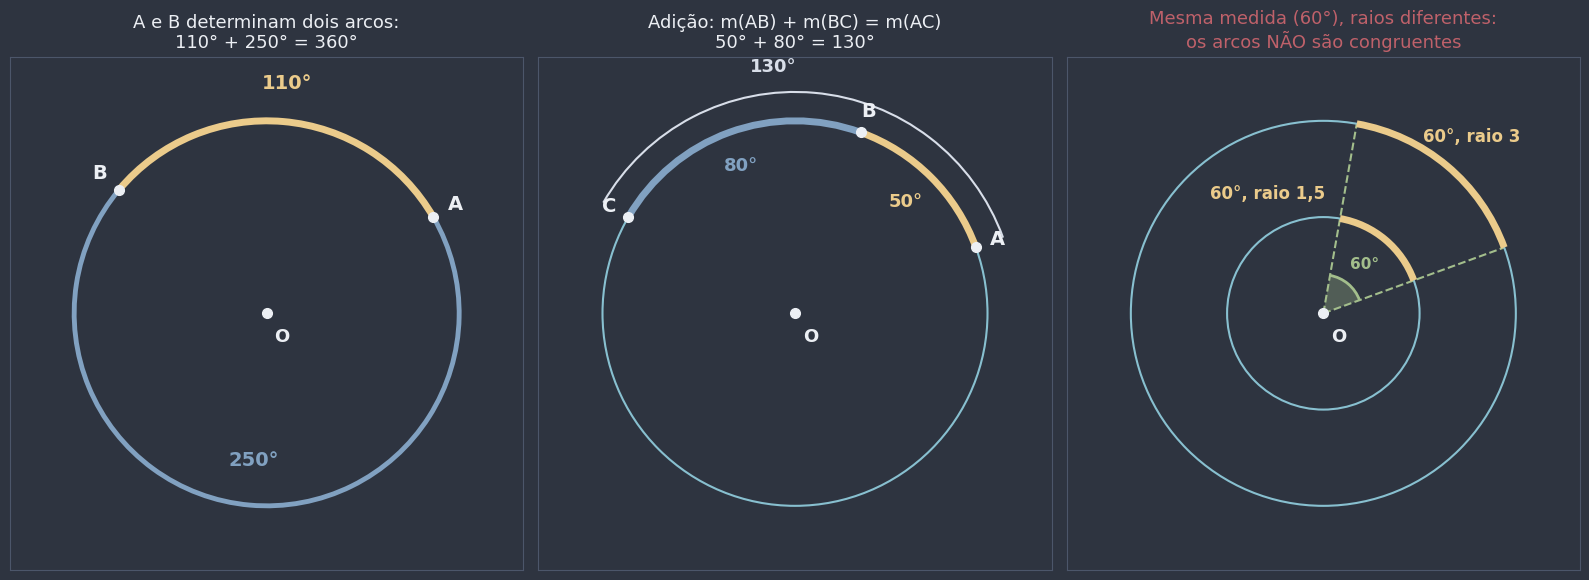

In [4]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 5.8))
fig.patch.set_facecolor(NORD_FUNDO)
for ax in eixos:
    preparar_eixo(ax, [(-r, -r), (r, r)], margem=1.0)
    desenhar_ponto(ax, O, "O", cor=COR_CENTRO, deslocamento=(0.12, -0.45))

# 1) Dois pontos, dois arcos
ax = eixos[0]
A, B = ponto_na_circunferencia(O, r, 30), ponto_na_circunferencia(O, r, 140)
menor, maior = arcos_determinados(O, A, B)
desenhar_arco_da_circunferencia(ax, O, r, 30, 140)
desenhar_arco_da_circunferencia(ax, O, r, 140, 30, cor=COR_ARCO_2, largura=3.5)
ax.text(*ponto_na_circunferencia(O, r + 0.6, 85), f"{menor:.0f}°", color=COR_ARCO, fontsize=14,
        fontweight="bold", ha="center", va="center")
ax.text(*ponto_na_circunferencia(O, r - 0.7, 265), f"{maior:.0f}°", color=COR_ARCO_2, fontsize=14,
        fontweight="bold", ha="center", va="center")
for P, nome in ((A, "A"), (B, "B")):
    desenhar_ponto(ax, P, cor=NORD_TEXTO)
    rotular_fora(ax, P, nome, O, distancia=0.4, tamanho=14)
ax.set_title(f"A e B determinam dois arcos:\n{menor:.0f}° + {maior:.0f}° = 360°", color=NORD_TEXTO, fontsize=13)

# 2) Adição de arcos consecutivos
ax = eixos[1]
desenhar_circunferencia(ax, O, r, largura=1.5)
A, B, C = (ponto_na_circunferencia(O, r, a) for a in (20, 70, 150))
desenhar_arco_da_circunferencia(ax, O, r, 20, 70)
desenhar_arco_da_circunferencia(ax, O, r, 70, 150, cor=COR_ARCO_2)
desenhar_arco_da_circunferencia(ax, O, r + 0.45, 20, 150, cor=NORD_TEXTO_SEC, largura=1.5)
ax.text(*ponto_na_circunferencia(O, r - 0.55, 45), "50°", color=COR_ARCO, fontsize=13, fontweight="bold",
        ha="center", va="center")
ax.text(*ponto_na_circunferencia(O, r - 0.55, 110), "80°", color=COR_ARCO_2, fontsize=13, fontweight="bold",
        ha="center", va="center")
ax.text(*ponto_na_circunferencia(O, r + 0.85, 95), "130°", color=NORD_TEXTO_SEC, fontsize=13,
        fontweight="bold", ha="center", va="center")
for P, nome in ((A, "A"), (B, "B"), (C, "C")):
    desenhar_ponto(ax, P, cor=NORD_TEXTO)
    rotular_fora(ax, P, nome, O, distancia=0.35, tamanho=14)
ax.set_title("Adição: m(AB) + m(BC) = m(AC)\n50° + 80° = 130°", color=NORD_TEXTO, fontsize=13)

# 3) Mesma medida, raios diferentes
ax = eixos[2]
for raio in (1.5, r):
    desenhar_circunferencia(ax, O, raio, largura=1.5)
    desenhar_arco_da_circunferencia(ax, O, raio, 20, 80)
for angulo in (20, 80):
    ax.plot(*zip(O, ponto_na_circunferencia(O, r, angulo)), color=COR_CENTRAL, lw=1.5, linestyle="--")
desenhar_setor(ax, O, 20, 60, raio=0.6, cor=COR_CENTRAL, rotulo="60°", raio_rotulo=1.0)
ax.text(*ponto_na_circunferencia(O, r + 0.6, 50), "60°, raio 3", color=COR_ARCO, fontsize=12,
        fontweight="bold", ha="center", va="center")
ax.text(*ponto_na_circunferencia(O, 1.5 + 0.55, 115), "60°, raio 1,5", color=COR_ARCO, fontsize=12,
        fontweight="bold", ha="center", va="center")
ax.set_title("Mesma medida (60°), raios diferentes:\nos arcos NÃO são congruentes", color=COR_ALERTA,
             fontsize=13)
plt.tight_layout()
plt.show()

⚠️ **Erro comum:** confundir a **medida angular** de um arco (em graus, que **não** depende do raio) com o **comprimento** do arco (em cm ou m, que **depende** do raio). Na terceira figura, os dois arcos medem 60°, mas o de fora é claramente mais **comprido**: ele tem o dobro do comprimento do de dentro. Por isso, arcos de mesma medida em circunferências de raios diferentes **não** são congruentes: não dá para sobrepor um ao outro. O cálculo do comprimento de um arco fica para 📌 Polígonos Regulares e Comprimento da Circunferência; aqui, os arcos são medidos **só em graus**.

### Arcos e cordas

Cada arco tem uma **corda**: o segmento que liga as suas extremidades (a corda "subtende" o arco, [`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb)). Numa mesma circunferência:

- **arcos congruentes têm cordas congruentes**, e, entre arcos menores que a semicircunferência, vale a recíproca: cordas congruentes têm arcos congruentes;
- entre arcos menores que a semicircunferência, **ao maior arco corresponde a maior corda**.

A primeira regra vem da congruência de triângulos: se $m(\overset{\frown}{AB}) = m(\overset{\frown}{CD})$, os triângulos $AOB$ e $COD$ têm dois lados iguais ao raio e o ângulo entre eles igual, então são congruentes pelo caso **LAL** ([`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb)), e $AB = CD$. A tabela abaixo mostra a segunda: com $A$ fixo, $B$ dá a volta na circunferência de raio 3, e a corda $\overline{AB}$ cresce até o arco chegar a 180° (a corda vira o diâmetro, 6). Depois, ela **volta a diminuir**: é por isso que a regra fala só de arcos menores que a semicircunferência.

In [5]:
A = ponto_na_circunferencia(O, r, 0)
linhas = []
for arco in range(0, 361, 30):
    B = ponto_na_circunferencia(O, r, arco)
    tipo = "semicircunferência" if arco == 180 else ("menor que 180°" if arco < 180 else "maior que 180°")
    linhas.append({"arco AB (de A até B, anti-horário)": f"{arco}°", "o arco é...": tipo,
                   "corda AB": f"{math.dist(A, B):.3f}"})
display(pd.DataFrame(linhas).style.hide(axis="index"))

"arco AB (de A até B, anti-horário)",o arco é...,corda AB
0°,menor que 180°,0.000
30°,menor que 180°,1.553
60°,menor que 180°,3.000
90°,menor que 180°,4.243
120°,menor que 180°,5.196
150°,menor que 180°,5.796
180°,semicircunferência,6.000
210°,maior que 180°,5.796
240°,maior que 180°,5.196
270°,maior que 180°,4.243


Os arcos de 150° e 210° têm a **mesma corda**, e não é por acaso: são os dois arcos determinados pelos mesmos pontos $A$ e $B$ (150° + 210° = 360°). Toda corda "serve" para dois arcos ao mesmo tempo.

🕹️ **Widget interativo:** os sliders `posição de A` e `posição de B` movem os dois pontos sobre a circunferência (a posição é a direção, em graus, vista do centro). O arco menor fica amarelo e o maior, azul, cada um com a sua medida; o painel mostra também o comprimento da corda $\overline{AB}$. Tente: (1) deixar $A$ e $B$ diametralmente opostos; (2) obter dois arcos menores **diferentes** com a **mesma** corda, mudando os dois pontos de lugar (dica: basta manter a mesma "distância em graus" entre eles).

In [ ]:
def explorar_arcos(posicao_A: int, posicao_B: int) -> None:
    O_w, r_w = np.array([0.0, 0.0]), 3.0
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(13.5, 6.4), gridspec_kw={"width_ratios": [1.15, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-r_w, -r_w), (r_w, r_w)], margem=1.0)
    desenhar_circunferencia(ax, O_w, r_w, largura=1.5)
    desenhar_ponto(ax, O_w, "O", cor=COR_CENTRO, deslocamento=(0.12, -0.45))
    if posicao_A % 360 == posicao_B % 360:
        ax.set_title("A = B: escolha dois pontos distintos", color=COR_ALERTA, fontsize=14)
        escrever_checklist(ax_lista, [("dois pontos iguais não determinam arcos", False)], "Arcos")
        plt.tight_layout()
        plt.show()
        return
    A_w, B_w = ponto_na_circunferencia(O_w, r_w, posicao_A), ponto_na_circunferencia(O_w, r_w, posicao_B)
    menor, maior = arcos_determinados(O_w, A_w, B_w)
    # O arco anti-horário de A até B é o menor ou o maior?
    if medida_arco(posicao_A, posicao_B) <= 180:
        inicio_menor, fim_menor = posicao_A, posicao_B
    else:
        inicio_menor, fim_menor = posicao_B, posicao_A
    diametro = iguais(menor, 180)
    desenhar_arco_da_circunferencia(ax, O_w, r_w, inicio_menor, fim_menor, cor=COR_ARCO)
    desenhar_arco_da_circunferencia(ax, O_w, r_w, fim_menor, inicio_menor, cor=COR_ARCO_2,
                                    largura=5.0 if diametro else 3.5)
    meio_menor = inicio_menor + menor / 2
    ax.text(*ponto_na_circunferencia(O_w, r_w + 0.6, meio_menor), f"{menor:.0f}°", color=COR_ARCO, fontsize=14,
            fontweight="bold", ha="center", va="center")
    ax.text(*ponto_na_circunferencia(O_w, r_w + 0.6, meio_menor + 180), f"{maior:.0f}°", color=COR_ARCO_2,
            fontsize=14, fontweight="bold", ha="center", va="center")
    corda = math.dist(A_w, B_w)
    ax.plot(*zip(A_w, B_w), color=NORD_TEXTO, lw=2.5, zorder=5)
    for P, nome in ((A_w, "A"), (B_w, "B")):
        desenhar_ponto(ax, P, cor=NORD_TEXTO)
        rotular_fora(ax, P, nome, O_w, distancia=0.35, tamanho=14)
    if diametro:
        ax.set_title("A e B diametralmente opostos: duas semicircunferências", color=COR_ARCO, fontsize=13)
    else:
        ax.set_title(f"arco menor {menor:.0f}° (amarelo)  e  arco maior {maior:.0f}° (azul)", color=NORD_TEXTO,
                     fontsize=13)
    itens = [
        (f"arco menor = {menor:.0f}°   e   arco maior = {maior:.0f}°", True),
        (f"soma dos dois arcos = {menor + maior:.0f}°", iguais(menor + maior, 360)),
        (f"corda AB = {corda:.3f}   (o diâmetro mede {2 * r_w:g})", True),
        ("AB é um diâmetro: os dois arcos medem 180°", diametro),
    ]
    escrever_checklist(ax_lista, itens, "Arcos determinados por A e B")
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_arcos,
    posicao_A=widgets.IntSlider(value=20, min=0, max=355, step=5, description="posição de A:"),
    posicao_B=widgets.IntSlider(value=130, min=0, max=355, step=5, description="posição de B:"),
);

interactive(children=(IntSlider(value=20, description='posição de A:', max=355, step=5), IntSlider(value=130, …

🎯 **Aplicação prática — rodas e engrenagens:** medir arcos em graus é o mesmo que medir **quanto uma peça girou**. Uma roda de bicicleta que dá um quarto de volta faz cada ponto do pneu percorrer um arco de 90°, seja a roda de uma bicicleta infantil ou a de uma mountain bike. A distância percorrida no chão (o comprimento do arco) é outra história, e essa sim depende do raio.

📎 **Conexão:** no módulo de Trigonometria, em [`0501a_arcos_e_angulos.ipynb`](../05_trigonometria/0501a_arcos_e_angulos.ipynb), os arcos voltam com uma nova unidade de medida, o **radiano**, que liga a medida angular ao comprimento. Neste notebook, tudo é medido **só em graus**.

📖 **Leitura complementar:** [Circular arc](https://en.wikipedia.org/wiki/Circular_arc) (em inglês)

**Pergunta de checagem:** dois arcos medem 50°. Eles são necessariamente congruentes? E se estiverem na mesma circunferência?

**Pergunta de checagem:** os pontos $A$, $B$ e $C$ estão nessa ordem numa circunferência, com $m(\overset{\frown}{AB}) = 75°$ e $m(\overset{\frown}{BC}) = 95°$ (arcos consecutivos). Quanto mede o arco $\overset{\frown}{AC}$ que passa por $B$? E o outro arco $\overset{\frown}{AC}$?

## 2. Ângulo central

📌 **Definição formal (ângulo central):** um **ângulo central** de uma circunferência é um ângulo cujo vértice é o **centro** $O$ e cujos lados são dois **raios**, $\overline{OA}$ e $\overline{OB}$. O arco $\overset{\frown}{AB}$ que fica dentro dele é o arco **correspondente** ao ângulo, e a regra é a própria definição de medida de arco:

$$m(A\hat{O}B) = m(\overset{\frown}{AB}).$$

O ângulo central é a **ponte** entre as duas medidas: é ele que dá sentido à frase "um arco de 90°". Algumas consequências imediatas:

- **ângulos centrais congruentes** determinam **arcos congruentes** e, pela seção 1, **cordas congruentes**;
- ângulos centrais consecutivos que dão a volta no centro somam **360°**, como as fatias de uma pizza (ângulos de uma volta, [`0403a_angulos.ipynb`](0403a_angulos.ipynb));
- se o ângulo central é **raso** (180°), os dois raios formam um **diâmetro**, e o arco é uma semicircunferência;
- um ângulo central **maior que 180°** (um ângulo côncavo, [`0403a_angulos.ipynb`](0403a_angulos.ipynb)) corresponde ao **arco maior**.

**No código:** a função `extremidades_do_arco` constrói as extremidades $A$ e $B$ de um arco a partir do ângulo central, usando a direção de cada ponto, vista do centro (essa "direção em graus" é só uma ferramenta de **construção** da figura). Depois, o transferidor digital mede o ângulo $A\hat{O}B$ para conferir. Atenção à última coluna: o transferidor só mede até 180°, então, para um ângulo central côncavo, ele devolve o **replemento** (o que falta para 360°).

In [7]:
def extremidades_do_arco(O, r: float, inicio: float, angulo_central: float) -> tuple[np.ndarray, np.ndarray]:
    """Extremidades A e B do arco que começa na direção `inicio` e mede `angulo_central` graus, no sentido
    anti-horário: são os pontos em que os dois lados do ângulo central cortam a circunferência."""
    return ponto_na_circunferencia(O, r, inicio), ponto_na_circunferencia(O, r, inicio + angulo_central)


linhas = []
for alfa in [30, 75, 90, 120, 180, 250, 300]:
    A, B = extremidades_do_arco(O, r, 10, alfa)
    medido = medir_angulo(O, A, B)
    linhas.append({"ângulo central dado": f"{alfa}°", "o transferidor mede AÔB": f"{medido:.1f}°",
                   "ângulo central": f"{medido:.1f}°" if alfa <= 180 else f"360° − {medido:.1f}° = {360 - medido:.1f}°",
                   "arco AB": f"{alfa}°", "corda AB": f"{math.dist(A, B):.3f}"})
display(pd.DataFrame(linhas).style.hide(axis="index"))

ângulo central dado,o transferidor mede AÔB,ângulo central,arco AB,corda AB
30°,30.0°,30.0°,30°,1.553
75°,75.0°,75.0°,75°,3.653
90°,90.0°,90.0°,90°,4.243
120°,120.0°,120.0°,120°,5.196
180°,180.0°,180.0°,180°,6.000
250°,110.0°,360° − 110.0° = 250.0°,250°,4.915
300°,60.0°,360° − 60.0° = 300.0°,300°,3.000


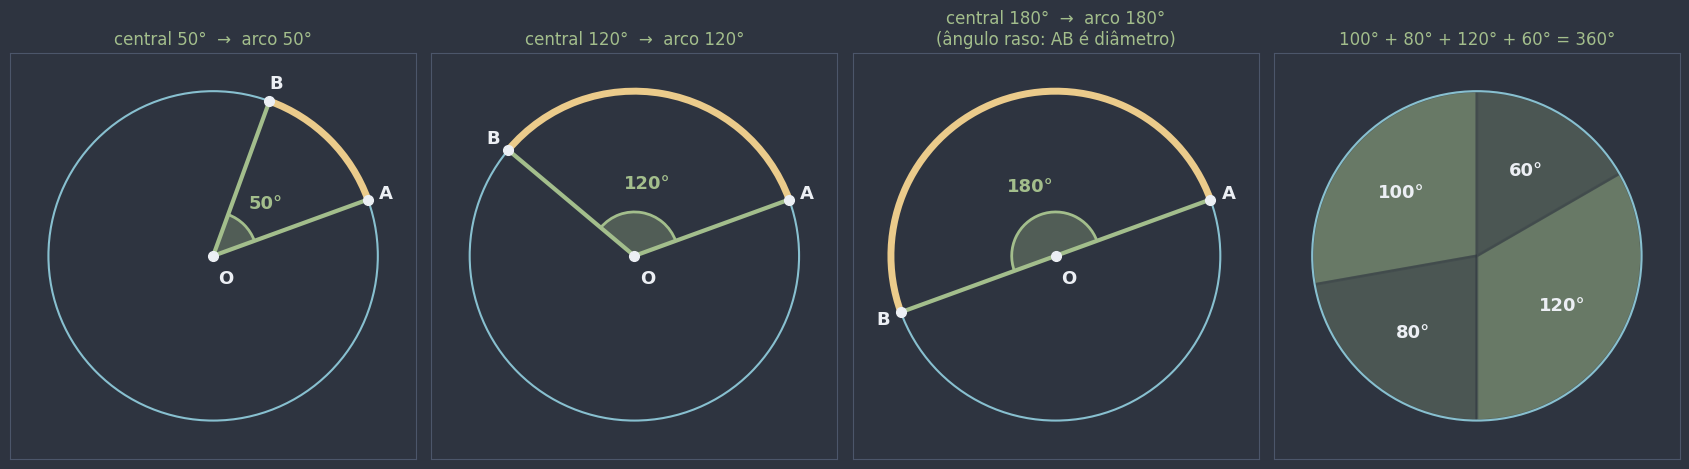

In [8]:
fig, eixos = plt.subplots(1, 4, figsize=(17, 4.9))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, alfa in zip(eixos[:3], (50, 120, 180)):
    preparar_eixo(ax, [(-r, -r), (r, r)], margem=0.7)
    desenhar_circunferencia(ax, O, r, largura=1.5)
    A, B = extremidades_do_arco(O, r, 20, alfa)
    desenhar_arco_da_circunferencia(ax, O, r, 20, 20 + alfa)
    for P, nome in ((A, "A"), (B, "B")):
        ax.plot(*zip(O, P), color=COR_CENTRAL, lw=3, zorder=5)
        desenhar_ponto(ax, P, cor=NORD_TEXTO)
        rotular_fora(ax, P, nome, O, distancia=0.35, tamanho=13)
    desenhar_setor(ax, O, 20, alfa, raio=0.8, cor=COR_CENTRAL, rotulo=f"{alfa}°", raio_rotulo=1.35,
                   tamanho_fonte=13)
    desenhar_ponto(ax, O, "O", cor=COR_CENTRO, deslocamento=(0.1, -0.5))
    extra = "\n(ângulo raso: AB é diâmetro)" if alfa == 180 else ""
    ax.set_title(f"central {alfa}°  →  arco {alfa}°{extra}", color=COR_CENTRAL, fontsize=12)

# A pizza: ângulos centrais consecutivos que dão a volta somam 360°
ax = eixos[3]
preparar_eixo(ax, [(-r, -r), (r, r)], margem=0.7)
inicio = 90
for k, fatia in enumerate([100, 80, 120, 60]):
    ax.add_patch(Wedge(tuple(O), r, inicio, inicio + fatia, facecolor=COR_CENTRAL,
                       alpha=0.5 if k % 2 == 0 else 0.25, edgecolor=NORD_FUNDO, lw=2))
    ax.text(*ponto_na_circunferencia(O, 0.6 * r, inicio + fatia / 2), f"{fatia}°", color=NORD_TEXTO,
            fontsize=13, fontweight="bold", ha="center", va="center")
    inicio += fatia
desenhar_circunferencia(ax, O, r, largura=1.5)
ax.set_title("100° + 80° + 120° + 60° = 360°", color=COR_CENTRAL, fontsize=12)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo — o relógio:** o ponteiro dos minutos é um **raio** que gira em torno do centro. O slider `minutos` avança o ponteiro a partir das 12 horas, e a região verde é o **ângulo central** que ele varreu; o arco amarelo é o arco correspondente. Como uma volta (360°) leva 60 minutos, cada minuto vale $360° \div 60 = 6°$. Procure os instantes em que o ângulo central é **reto** e **raso**.

In [9]:
def explorar_relogio(minutos: int) -> None:
    O_w, r_w = np.array([0.0, 0.0]), 3.0
    angulo_central = 6 * minutos
    ponteiro = 90 - angulo_central  # o ponteiro gira no sentido horário, a partir das 12 horas
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(13.5, 6.4), gridspec_kw={"width_ratios": [1.15, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-r_w, -r_w), (r_w, r_w)], margem=0.6)
    desenhar_circunferencia(ax, O_w, r_w, largura=3)
    # Marcas das horas
    for hora in range(12):
        direcao_hora = 90 - 30 * hora
        ax.plot(*zip(ponto_na_circunferencia(O_w, r_w - 0.3, direcao_hora),
                     ponto_na_circunferencia(O_w, r_w, direcao_hora)), color=NORD_TEXTO_SEC, lw=2)
        if hora % 3 == 0:
            ax.text(*ponto_na_circunferencia(O_w, r_w - 0.65, direcao_hora), str(hora or 12), color=NORD_TEXTO,
                    fontsize=14, fontweight="bold", ha="center", va="center")
    if minutos > 0:
        desenhar_setor(ax, O_w, ponteiro, angulo_central, raio=r_w * 0.85, cor=COR_CENTRAL, marcar_reto=False)
        desenhar_arco_da_circunferencia(ax, O_w, r_w, ponteiro, ponteiro + angulo_central)
    ax.plot(*zip(O_w, ponto_na_circunferencia(O_w, r_w, 90)), color=COR_CENTRAL, lw=2, linestyle="--", zorder=5)
    ax.plot(*zip(O_w, ponto_na_circunferencia(O_w, 0.9 * r_w, ponteiro)), color=NORD_TEXTO, lw=4,
            solid_capstyle="round", zorder=6)
    ax.plot(*O_w, "o", color=NORD_TEXTO, markersize=10, zorder=7)
    ax.set_title(f"{minutos} min  →  ângulo central = arco = 6° × {minutos} = {angulo_central}°", color=COR_CENTRAL,
                 fontsize=13)
    itens = [
        (f"ângulo central = {angulo_central}°   e   arco = {angulo_central}°", True),
        ("ângulo central agudo (menor que 90°)", 0 < angulo_central < 90),
        ("ângulo central reto (90°): um quarto de volta", angulo_central == 90),
        ("ângulo central raso (180°): ponteiro e 12 h formam um diâmetro", angulo_central == 180),
        ("ângulo central côncavo (maior que 180°): arco maior", 180 < angulo_central < 360),
        ("uma volta completa: 360°", angulo_central == 360),
    ]
    escrever_checklist(ax_lista, itens, "1 minuto = 6°")
    plt.tight_layout()
    plt.show()


widgets.interact(explorar_relogio, minutos=widgets.IntSlider(value=10, min=0, max=60, step=1, description="minutos:"));

interactive(children=(IntSlider(value=10, description='minutos:', max=60), Output()), _dom_classes=('widget-in…

💡 **Dica:** sempre que um problema falar de um arco "de tantos graus", imagine o ângulo central correspondente; é ele que carrega a medida. E vice-versa: um ângulo central de $\alpha$ graus "recorta" na circunferência um arco de $\alpha$ graus, qualquer que seja o raio.

📎 **Conexão:** num **polígono regular** de $n$ lados inscrito numa circunferência, os $n$ lados são cordas congruentes, então os $n$ ângulos centrais também são congruentes e dão a volta no centro: cada um mede $\dfrac{360°}{n}$. No hexágono regular, por exemplo, 60°. Isso será usado em 📌 Polígonos Regulares e Comprimento da Circunferência.

**Pergunta de checagem:** um ângulo central mede 75°. Qual é a medida do arco correspondente? E a do arco maior, o restante da circunferência?

**Pergunta de checagem:** quantos graus o ponteiro dos minutos varre em 25 minutos? E o ponteiro das **horas**, no mesmo tempo? (Dica: ele dá uma volta em 12 horas.)

## 3. Ângulo inscrito

Agora o vértice sai do centro e vai para a **própria circunferência**.

📌 **Definição formal (ângulo inscrito):** um **ângulo inscrito** numa circunferência é um ângulo cujo vértice $V$ **pertence à circunferência** e cujos lados são **duas cordas**, $\overline{VA}$ e $\overline{VB}$. O arco $\overset{\frown}{AB}$ que fica **dentro** do ângulo (o que **não** contém $V$) é o arco que o ângulo **enxerga**.

📌 **Teorema do ângulo inscrito:** a medida de um ângulo inscrito é **a metade** da medida do arco que ele enxerga:

$$m(A\hat{V}B) = \frac{m(\overset{\frown}{AB})}{2}.$$

Dito de outro modo: o ângulo inscrito vale **metade do ângulo central** que enxerga o mesmo arco.

### Por que vale? Uma demonstração em três casos

O que muda de um caso para outro é a posição do centro $O$ em relação ao ângulo.

**Caso 1: um lado do ângulo passa pelo centro** (uma das cordas, $\overline{VA}$, é um diâmetro). Ligue $O$ a $B$. O triângulo $VOB$ é **isósceles**, porque $OV = OB$ (dois raios). Então os ângulos da base são congruentes ([`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb)): $O\hat{V}B = O\hat{B}V = \alpha$. O ângulo central $A\hat{O}B$ é um **ângulo externo** do triângulo $VOB$ (ele é o suplemento de $V\hat{O}B$, já que $V$, $O$ e $A$ estão alinhados), e o ângulo externo é igual à soma dos dois internos não adjacentes ([`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb)):

$$m(A\hat{O}B) = \alpha + \alpha = 2\alpha \quad\Longrightarrow\quad \alpha = \frac{m(A\hat{O}B)}{2} = \frac{m(\overset{\frown}{AB})}{2}.$$

**Caso 2: o centro está dentro do ângulo.** Trace o diâmetro $\overline{VD}$. Ele divide o ângulo em dois ângulos inscritos, cada um com um lado passando pelo centro, e o caso 1 vale para cada um. **Somando:** $m(A\hat{V}B) = \dfrac{m(\overset{\frown}{AD})}{2} + \dfrac{m(\overset{\frown}{DB})}{2} = \dfrac{m(\overset{\frown}{AB})}{2}$.

**Caso 3: o centro está fora do ângulo.** Trace de novo o diâmetro $\overline{VD}$. Agora o ângulo $A\hat{V}B$ é a **diferença** de dois ângulos do caso 1: $m(A\hat{V}B) = \dfrac{m(\overset{\frown}{AD})}{2} - \dfrac{m(\overset{\frown}{BD})}{2} = \dfrac{m(\overset{\frown}{AB})}{2}$.

As três figuras abaixo mostram os três casos, com o ângulo inscrito em roxo, o central em verde e o diâmetro auxiliar tracejado. Os títulos trazem as medidas feitas pelo transferidor digital.

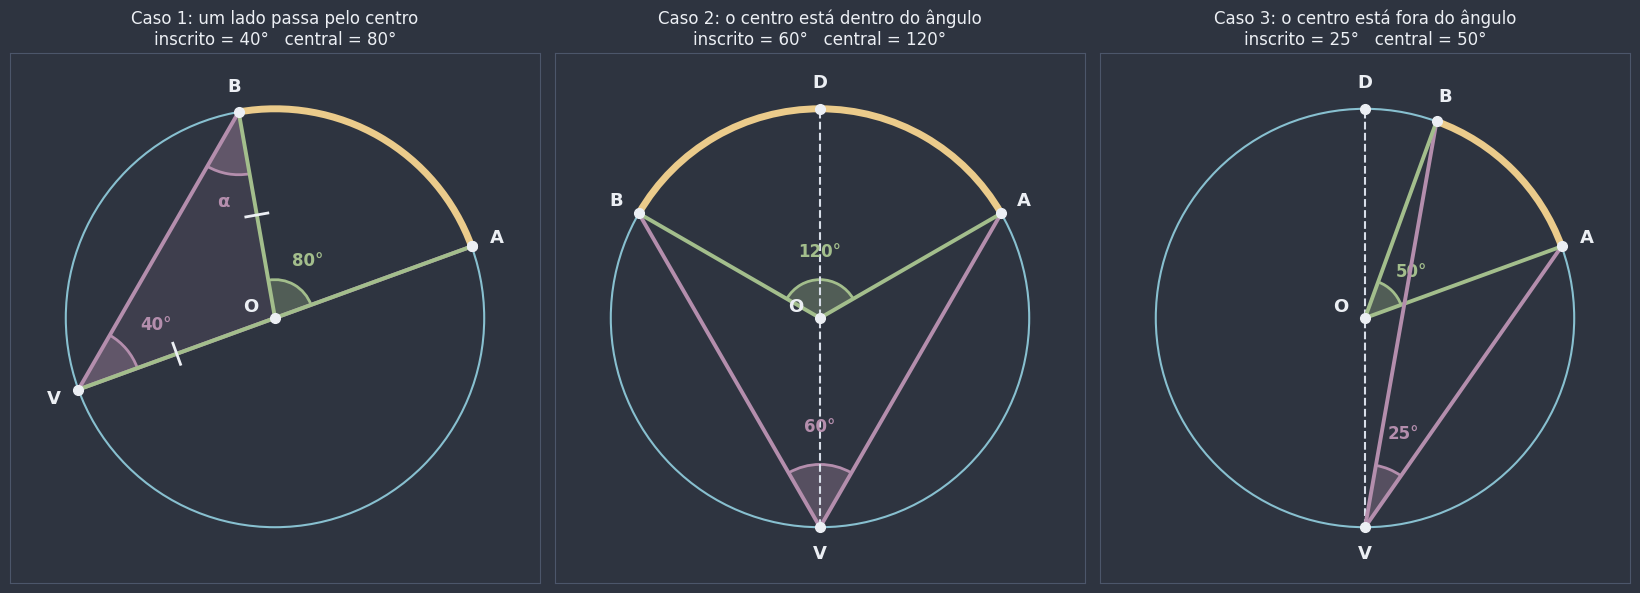

In [10]:
casos = [
    ("Caso 1: um lado passa pelo centro", 200, 20, 100),
    ("Caso 2: o centro está dentro do ângulo", 270, 30, 150),
    ("Caso 3: o centro está fora do ângulo", 270, 20, 70),
]
fig, eixos = plt.subplots(1, 3, figsize=(16.5, 6))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (titulo, posicao_V, posicao_A, posicao_B) in zip(eixos, casos):
    preparar_eixo(ax, [(-r, -r), (r, r)], margem=0.8)
    desenhar_circunferencia(ax, O, r, largura=1.5)
    V, A, B = (ponto_na_circunferencia(O, r, a) for a in (posicao_V, posicao_A, posicao_B))
    D = ponto_na_circunferencia(O, r, posicao_V + 180)  # a outra ponta do diâmetro que sai de V
    desenhar_arco_enxergado(ax, O, r, V, A, B)
    ax.plot(*zip(V, D), color=NORD_TEXTO_SEC, lw=1.5, linestyle="--", zorder=3)
    for P in (A, B):
        ax.plot(*zip(V, P), color=COR_INSCRITO, lw=2.8, zorder=5)
        ax.plot(*zip(O, P), color=COR_CENTRAL, lw=2.8, zorder=5)
    inscrito, central = medir_angulo(V, A, B), medir_angulo(O, A, B)
    desenhar_arco(ax, V, A, B, raio=0.9, cor=COR_INSCRITO, rotulo=f"{inscrito:.0f}°", raio_rotulo=1.45,
                  tamanho_fonte=12)
    desenhar_arco(ax, O, A, B, raio=0.55, cor=COR_CENTRAL, rotulo=f"{central:.0f}°", raio_rotulo=0.95,
                  tamanho_fonte=12)
    caso_1 = (posicao_V - posicao_A) % 360 == 180  # o lado VA é um diâmetro
    if caso_1:  # o triângulo isósceles VOB
        ax.add_patch(Polygon([V, O, B], closed=True, facecolor=COR_INSCRITO, alpha=0.12, edgecolor="none"))
        ax.plot(*zip(O, V), color=COR_CENTRAL, lw=2.8, zorder=5)
        marcar_congruentes(ax, O, V)
        marcar_congruentes(ax, O, B)
        desenhar_arco(ax, B, V, O, raio=0.9, cor=COR_INSCRITO, rotulo="α", raio_rotulo=1.3, tamanho_fonte=13)
    for P, nome in ((V, "V"), (A, "A"), (B, "B"), (D, "" if caso_1 else "D")):
        desenhar_ponto(ax, P, cor=NORD_TEXTO)
        rotular_fora(ax, P, nome, O, distancia=0.38, tamanho=13)
    desenhar_ponto(ax, O, "O", cor=COR_CENTRO, deslocamento=(-0.45, 0.1))
    ax.set_title(f"{titulo}\ninscrito = {inscrito:.0f}°   central = {central:.0f}°", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

No caso 1, o ponto $D$ coincide com $A$ (o próprio lado $\overline{VA}$ já é o diâmetro), e os dois ângulos $\alpha$ do triângulo isósceles aparecem marcados. Nos três casos, o ângulo central é exatamente o dobro do inscrito.

**No código:** a função `arco_enxergado(O, V, A, B)` (definida na primeira célula) devolve a medida do arco $\overset{\frown}{AB}$ que **não** contém o vértice $V$. Com ela, dá para testar o teorema numericamente. Fixamos o arco $\overset{\frown}{AB}$ e colocamos o vértice $V$ em várias posições do outro arco:

In [11]:
A, B = ponto_na_circunferencia(O, r, 200), ponto_na_circunferencia(O, r, 320)
linhas = []
for posicao_V in [10, 45, 90, 135, 170]:
    V = ponto_na_circunferencia(O, r, posicao_V)
    arco = arco_enxergado(O, V, A, B)
    linhas.append({"V na direção": f"{posicao_V}°", "ângulo inscrito AV̂B (medido)": f"{medir_angulo(V, A, B):.4f}°",
                   "arco enxergado": f"{arco:.1f}°", "arco ÷ 2": f"{arco / 2:.4f}°",
                   "ângulo central AÔB": f"{medir_angulo(O, A, B):.4f}°"})
display(pd.DataFrame(linhas).style.hide(axis="index"))

V na direção,ângulo inscrito AV̂B (medido),arco enxergado,arco ÷ 2,ângulo central AÔB
10°,60.0000°,120.0°,60.0000°,120.0000°
45°,60.0000°,120.0°,60.0000°,120.0000°
90°,60.0000°,120.0°,60.0000°,120.0000°
135°,60.0000°,120.0°,60.0000°,120.0000°
170°,60.0000°,120.0°,60.0000°,120.0000°


O vértice mudou de lugar cinco vezes, e o ângulo inscrito ficou **parado** em 60°: metade dos 120° do arco (e do ângulo central). É a explicação do gancho: todos os pontos do arco "veem" o gol sob o mesmo ângulo.

🕹️ **Widget interativo:** o slider `arco AB` muda o arco enxergado (amarelo), e o slider `posição de V` move o vértice do ângulo inscrito (roxo) pelo outro arco. O ângulo central (verde) fica fixo enquanto $V$ anda. Observe a razão no painel. Depois, leve o `arco AB` até **180°** e veja o que acontece com o ângulo inscrito; e passe dos 180° para ver um ângulo inscrito **obtuso**.

In [ ]:
def explorar_inscrito(arco_AB: int, posicao_V: int) -> None:
    O_w, r_w = np.array([0.0, 0.0]), 3.0
    inicio_A = 270 - arco_AB / 2  # o arco AB fica embaixo, simétrico
    A_w, B_w = ponto_na_circunferencia(O_w, r_w, inicio_A), ponto_na_circunferencia(O_w, r_w, inicio_A + arco_AB)
    # V anda pelo outro arco (de B até A, no sentido anti-horário), sem encostar nas pontas
    V_w = ponto_na_circunferencia(O_w, r_w, inicio_A + arco_AB + (360 - arco_AB) * (0.05 + 0.9 * posicao_V / 100))
    inscrito = medir_angulo(V_w, A_w, B_w)
    central = arco_AB  # o ângulo central que enxerga o arco AB (pode passar de 180°)

    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(13.5, 6.4), gridspec_kw={"width_ratios": [1.15, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-r_w, -r_w), (r_w, r_w)], margem=0.8)
    desenhar_circunferencia(ax, O_w, r_w, largura=1.5)
    desenhar_arco_da_circunferencia(ax, O_w, r_w, inicio_A, inicio_A + arco_AB)
    desenhar_setor(ax, O_w, inicio_A, arco_AB, raio=0.6, cor=COR_CENTRAL, rotulo=f"{central}°", raio_rotulo=1.0,
                   tamanho_fonte=12)
    for P in (A_w, B_w):
        ax.plot(*zip(O_w, P), color=COR_CENTRAL, lw=2.5, zorder=5)
        ax.plot(*zip(V_w, P), color=COR_INSCRITO, lw=2.8, zorder=5)
    desenhar_arco(ax, V_w, A_w, B_w, raio=0.8, cor=COR_INSCRITO, rotulo=f"{inscrito:.1f}°", raio_rotulo=1.4,
                  tamanho_fonte=12)
    for P, nome in ((A_w, "A"), (B_w, "B"), (V_w, "V")):
        desenhar_ponto(ax, P, cor=NORD_TEXTO)
        rotular_fora(ax, P, nome, O_w, distancia=0.38, tamanho=14)
    desenhar_ponto(ax, O_w, "O", cor=COR_CENTRO, deslocamento=(0.12, 0.15))
    semi = arco_AB == 180
    ax.set_title("AB é diâmetro: o ângulo inscrito é RETO" if semi else f"inscrito {inscrito:.1f}°  =  arco {arco_AB}° ÷ 2",
                 color=COR_INSCRITO, fontsize=13)
    itens = [
        (f"ângulo inscrito ∠AVB = {inscrito:.2f}°", True),
        (f"ângulo central ∠AOB = arco AB = {central}°", True),
        (f"inscrito ÷ central = {inscrito / central:.3f}", iguais(inscrito / central, 0.5)),
        ("arco de 180° (semicircunferência): ângulo reto", semi and iguais(inscrito, 90)),
        ("arco maior que 180°: ângulo inscrito obtuso", arco_AB > 180),
    ]
    escrever_checklist(ax_lista, itens, "Teorema do ângulo inscrito")
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_inscrito,
    arco_AB=widgets.IntSlider(value=100, min=20, max=320, step=10, description="arco AB:"),
    posicao_V=widgets.IntSlider(value=30, min=0, max=100, step=5, description="posição de V:"),
);

interactive(children=(IntSlider(value=100, description='arco AB:', max=320, min=20, step=10), IntSlider(value=…

### Três consequências

**1. Ângulos inscritos que enxergam o mesmo arco são congruentes.** Todos valem a metade do mesmo arco. É a resposta do gancho e o que a tabela e o widget mostraram.

**2. Triângulo retângulo inscrito numa semicircunferência.** Se $\overline{AB}$ é um diâmetro e $P$ é qualquer outro ponto da circunferência, o ângulo $A\hat{P}B$ enxerga uma semicircunferência (180°), então

$$m(A\hat{P}B) = \frac{180°}{2} = 90°.$$

**Todo triângulo inscrito numa semicircunferência (com um lado sendo o diâmetro) é retângulo**, com o ângulo reto no vértice que está na circunferência. A **recíproca** também vale: em todo triângulo retângulo, a hipotenusa é um diâmetro da circunferência circunscrita, ou seja, o **circuncentro é o ponto médio da hipotenusa**. Essa é a promessa feita em [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb), sendo cumprida agora.

**3. Arcos congruentes ↔ ângulos inscritos congruentes** (numa mesma circunferência): se os arcos têm a mesma medida, as metades também têm; e vice-versa.

A figura abaixo mostra a consequência 2: cinco pontos diferentes da semicircunferência, cinco ângulos retos. A tabela ao lado testa a recíproca em triângulos retângulos sorteados (em posições e tamanhos aleatórios), comparando o circuncentro (calculado pelas mediatrizes, como em [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb)) com o ponto médio da hipotenusa.

ângulo AP1B = 90.000000°
ângulo AP2B = 90.000000°
ângulo AP3B = 90.000000°
ângulo AP4B = 90.000000°
ângulo AP5B = 90.000000°


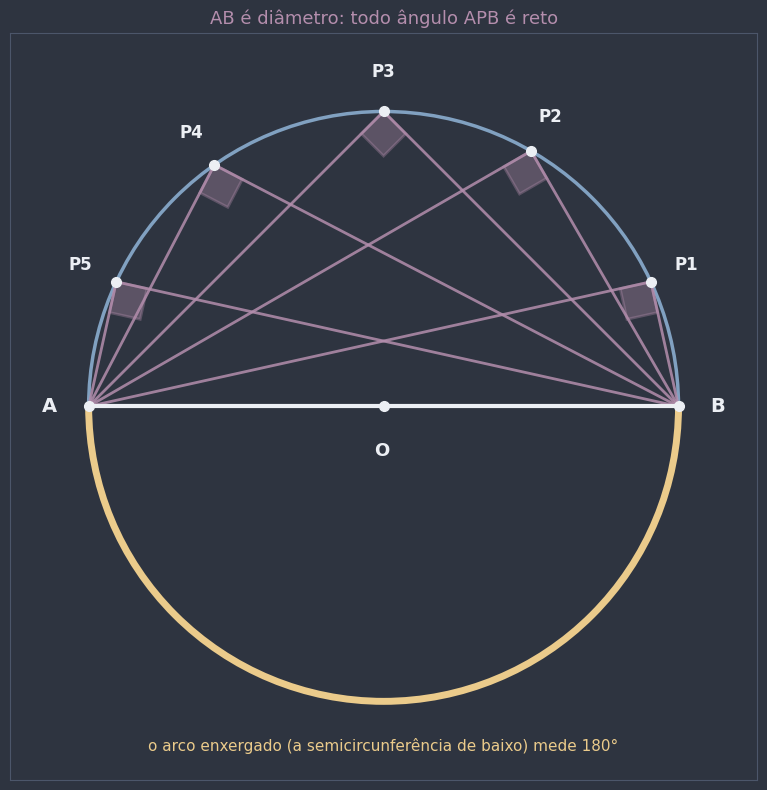

ângulo em C,circuncentro,ponto médio da hipotenusa AB,coincidem?
90.0°,"(-3.549, 2.966)","(-3.549, 2.966)",sim
90.0°,"(1.931, -1.212)","(1.931, -1.212)",sim
90.0°,"(1.147, 2.404)","(1.147, 2.404)",sim
90.0°,"(1.458, -2.970)","(1.458, -2.970)",sim
90.0°,"(0.832, -3.576)","(0.832, -3.576)",sim


In [13]:
A, B = ponto_na_circunferencia(O, r, 180), ponto_na_circunferencia(O, r, 0)
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-r, -r), (r, r)], margem=0.8)
desenhar_arco_da_circunferencia(ax, O, r, 0, 180, cor=COR_ARCO_2, largura=2.5)
desenhar_arco_da_circunferencia(ax, O, r, 180, 360, cor=COR_ARCO, largura=5)
ax.plot(*zip(A, B), color=NORD_TEXTO, lw=3, zorder=5)
for k, posicao_P in enumerate([25, 60, 90, 125, 155]):
    P = ponto_na_circunferencia(O, r, posicao_P)
    ax.plot(*zip(A, P, B), color=COR_INSCRITO, lw=2, alpha=0.85, zorder=4)
    marcar_angulo_reto(ax, P, A, B, tamanho=0.32, cor=COR_INSCRITO)
    desenhar_ponto(ax, P, cor=NORD_TEXTO)
    rotular_fora(ax, P, f"P{k + 1}", O, distancia=0.4, tamanho=12)
    print(f"ângulo AP{k + 1}B = {medir_angulo(P, A, B):.6f}°")
for P, nome in ((A, "A"), (B, "B")):
    desenhar_ponto(ax, P, cor=NORD_TEXTO)
    rotular_fora(ax, P, nome, O, distancia=0.4, tamanho=14)
desenhar_ponto(ax, O, "O", cor=COR_CENTRO, deslocamento=(-0.1, -0.5))
ax.text(0, -r - 0.5, "o arco enxergado (a semicircunferência de baixo) mede 180°", color=COR_ARCO, fontsize=11,
        ha="center")
ax.set_title("AB é diâmetro: todo ângulo APB é reto", color=COR_INSCRITO, fontsize=13)
plt.tight_layout()
plt.show()

# A recíproca: o circuncentro de um triângulo retângulo é o ponto médio da hipotenusa
gerador = np.random.default_rng(413)
linhas = []
for _ in range(5):
    C = gerador.uniform(-4, 4, 2)  # o vértice do ângulo reto
    giro = gerador.uniform(0, 360)
    cateto_1, cateto_2 = gerador.uniform(1, 6, 2)
    A_t, B_t = C + cateto_1 * direcao(giro), C + cateto_2 * direcao(giro + 90)
    centro, M = circuncentro(A_t, B_t, C), ponto_medio(A_t, B_t)
    linhas.append({"ângulo em C": f"{medir_angulo(C, A_t, B_t):.1f}°",
                   "circuncentro": f"({centro[0]:.3f}, {centro[1]:.3f})",
                   "ponto médio da hipotenusa AB": f"({M[0]:.3f}, {M[1]:.3f})",
                   "coincidem?": "sim" if np.allclose(centro, M) else "não"})
display(pd.DataFrame(linhas).style.hide(axis="index"))

🕵️ **Curiosidade histórica:** o resultado "todo ângulo inscrito numa semicircunferência é reto" é atribuído a **Tales de Mileto** (século VI a.C.), um dos primeiros matemáticos gregos de quem se tem notícia; segundo uma lenda, ele teria sacrificado um boi para comemorar a descoberta. Por isso, algumas fontes o chamam de "Teorema de Tales". **Cuidado:** no Brasil, o nome "Teorema de Tales" costuma indicar **outro** resultado, sobre um feixe de retas paralelas cortado por transversais e a proporcionalidade dos segmentos, que é o tema de 📌 Teorema de Tales (feixe de paralelas e proporcionalidade). Neste notebook, o resultado da semicircunferência é chamado só pelo nome descritivo: **triângulo retângulo inscrito numa semicircunferência**.

### O arco capaz, o gancho resolvido

📌 **Arco capaz:** dados um segmento $\overline{AB}$ e um ângulo $\alpha$ (entre 0° e 180°), o **lugar geométrico** dos pontos $P$ do plano que enxergam $\overline{AB}$ sob o ângulo $\alpha$ (isto é, com $m(A\hat{P}B) = \alpha$) é formado por **dois arcos de circunferência** de extremidades $A$ e $B$, simétricos em relação à reta $\overleftrightarrow{AB}$ (um de cada lado). Cada um deles se chama **arco capaz** de $\alpha$ sobre $\overline{AB}$.

Os pontos do arco capaz enxergam $\overline{AB}$ sob o ângulo $\alpha$ pelo teorema do ângulo inscrito: todos são vértices de ângulos inscritos que enxergam o mesmo arco, de medida $2\alpha$. A parte mais difícil, que fica sem demonstração aqui, é que **nenhum outro ponto** do plano tem essa propriedade: um ponto **dentro** da circunferência enxerga $\overline{AB}$ sob um ângulo maior, e um ponto **fora**, sob um ângulo menor (a seção 6 vai mostrar por quê).

É o **quarto lugar geométrico** do curso, depois da mediatriz, da bissetriz e da circunferência. No gancho, a curva do fotógrafo era o arco capaz de 40° sobre o gol: o arco **do outro lado** (abaixo da linha do gol) mede $2 \times 40° = 80°$. Um caso especial muito útil: o arco capaz de **90°** sobre $\overline{AB}$ é a circunferência de **diâmetro** $\overline{AB}$ (a consequência 2).

⚠️ **Erro comum:** aplicar a "metade do arco" ao **arco errado**. O ângulo inscrito enxerga o arco que fica **dentro** dele, do lado **oposto** ao vértice, e não o arco que contém o vértice. No widget, com o arco $\overset{\frown}{AB}$ de 100°, o ângulo inscrito mede 50°, e não $\frac{260°}{2} = 130°$. (Um ângulo de 130° apareceria se o vértice estivesse do **outro** lado, sobre o arco de 100°.)

🎯 **Aplicação prática — o ângulo de chute:** em análise de desempenho no futebol, mede-se o **ângulo de chute**: o ângulo sob o qual o jogador vê o gol. Quanto maior, mais fácil marcar. Pelo arco capaz, as posições com o mesmo ângulo de chute formam arcos que passam pelas traves; por isso, quando um ponta corre paralelo à linha lateral, existe um ponto em que o ângulo de chute é **máximo**: aquele em que a sua linha de corrida **tangencia** um desses arcos. O mesmo raciocínio serve para posicionar câmeras de segurança e para decidir onde ficar numa sala de cinema.

📖 **Leitura complementar:** [Ângulo inscrito](https://pt.wikipedia.org/wiki/%C3%82ngulo_inscrito), [Teorema de Tales (círculo)](https://pt.wikipedia.org/wiki/Teorema_de_Tales_(c%C3%ADrculo)), [Arco capaz](https://pt.wikipedia.org/wiki/Arco_capaz) e [Subtended angle](https://en.wikipedia.org/wiki/Subtended_angle) (em inglês). Para não confundir os nomes: [Teorema de Tales (interseção)](https://pt.wikipedia.org/wiki/Teorema_de_Tales_(interse%C3%A7%C3%A3o)), o "outro" Teorema de Tales.

**Pergunta de checagem:** um ângulo inscrito enxerga um arco de 110°. Quanto ele mede? E quanto mediria o ângulo central que enxerga o mesmo arco?

**Pergunta de checagem:** um triângulo $ABC$ está inscrito numa circunferência, e o lado $\overline{AB}$ passa pelo centro. Se $\hat{A} = 35°$, quanto medem $\hat{C}$ e $\hat{B}$?

## 4. Quadrilátero inscritível

Em [`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb), o teorema de Pitot decidiu quais quadriláteros admitem uma circunferência **inscrita**, tangente aos quatro lados. A pergunta agora é a outra: quais quadriláteros admitem uma circunferência que **passa pelos quatro vértices**?

📌 **Definição formal (quadrilátero inscritível):** um quadrilátero é **inscritível** (ou **cíclico**) quando seus quatro vértices pertencem a uma mesma circunferência. Diz-se então que o quadrilátero está **inscrito** na circunferência.

Para três pontos não colineares, sempre existe uma circunferência que passa por eles (a circunscrita ao triângulo, com centro no circuncentro). Com quatro pontos, é preciso sorte: a circunferência que passa por $A$, $B$ e $C$ pode ou não passar por $D$. O teste é com ângulos.

📌 **Propriedade:** num quadrilátero inscrito, **os ângulos opostos são suplementares**:

$$\hat{A} + \hat{C} = 180° \qquad\text{e}\qquad \hat{B} + \hat{D} = 180°.$$

**Por quê?** Os ângulos $\hat{A}$ e $\hat{C}$ são ângulos **inscritos**. O ângulo $\hat{A} = D\hat{A}B$ enxerga o arco $\overset{\frown}{BCD}$ (o que passa por $C$), e o ângulo $\hat{C} = B\hat{C}D$ enxerga o arco $\overset{\frown}{DAB}$ (o que passa por $A$). Esses dois arcos, juntos, formam a circunferência inteira. Pelo teorema do ângulo inscrito (seção 3):

$$\hat{A} + \hat{C} = \frac{m(\overset{\frown}{BCD})}{2} + \frac{m(\overset{\frown}{DAB})}{2} = \frac{360°}{2} = 180°.$$

O mesmo raciocínio vale para $\hat{B}$ e $\hat{D}$ (ou, mais rápido: a soma dos quatro ângulos internos de um quadrilátero é 360°, [`0411a_poligonos.ipynb`](0411a_poligonos.ipynb)).

📌 **Recíproca:** um quadrilátero **convexo** com um par de ângulos opostos suplementares é inscritível. (A demonstração fica de fora; o código abaixo vai conferir o fato verificando que o quarto vértice cai sobre a circunferência dos outros três.)

**Uma consequência:** num quadrilátero inscrito, o **ângulo externo** em um vértice é congruente ao **ângulo interno oposto**. O ângulo externo em $A$ é o suplemento de $\hat{A}$, e $\hat{C}$ também é. Logo, os dois são iguais.

**Quadriláteros conhecidos** ([`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb) e [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb)):

- o **retângulo** é inscritível: os quatro ângulos são retos, então os opostos somam 180°. O centro é o encontro das diagonais, que são congruentes e se cortam ao meio (o que já mostrava que os quatro vértices estão à mesma distância desse ponto);
- o **quadrado**, por ser um retângulo, também;
- o **trapézio isósceles** é inscritível: os ângulos de uma mesma base são congruentes, e os de um mesmo lado oblíquo são suplementares, então os opostos somam 180°;
- o **paralelogramo** que não é retângulo **não** é: os ângulos opostos são congruentes, e só somariam 180° se fossem retos. O mesmo vale para o **losango** que não é quadrado.

**No código:** a função `eh_inscritivel` mede os ângulos internos com o transferidor digital e testa se os opostos somam 180°. Na última coluna, uma conferência independente: o quarto vértice $D$ está sobre a circunferência que passa por $A$, $B$ e $C$ (com centro no circuncentro do triângulo $ABC$)?

In [14]:
def angulos_internos(vertices) -> list[float]:
    """Ângulos internos, em graus, de um quadrilátero CONVEXO, medidos em cada vértice entre os dois vizinhos."""
    return [medir_angulo(vertices[k], vertices[k - 1], vertices[(k + 1) % 4]) for k in range(4)]


def eh_inscritivel(A, B, C, D) -> bool:
    """True se o quadrilátero convexo ABCD é inscritível: os ângulos opostos são suplementares."""
    angulo_A, angulo_B, angulo_C, angulo_D = angulos_internos([A, B, C, D])
    return iguais(angulo_A + angulo_C, 180) and iguais(angulo_B + angulo_D, 180)


def quarto_vertice_na_circunferencia(A, B, C, D) -> bool:
    """Conferência independente: D está sobre a circunferência que passa por A, B e C?"""
    centro = circuncentro(A, B, C)
    return iguais(math.dist(centro, D), math.dist(centro, A))


exemplos_quadrilateros = {
    "retângulo 6 × 3": [(0, 0), (6, 0), (6, 3), (0, 3)],
    "quadrado de lado 4": [(0, 0), (4, 0), (4, 4), (0, 4)],
    "trapézio isósceles": [(0, 0), (8, 0), (5.5, 4), (2.5, 4)],
    "paralelogramo": [(0, 0), (6, 0), (8, 3), (2, 3)],
    "losango de lado 5": [(0, 0), (5, 0), (8, 4), (3, 4)],
    "quatro pontos de uma circunferência": [tuple(ponto_na_circunferencia((0, 0), 3, a)) for a in (300, 20, 110, 200)],
}
linhas = []
for nome, vertices in exemplos_quadrilateros.items():
    angulo_A, angulo_B, angulo_C, angulo_D = angulos_internos(vertices)
    linhas.append({"quadrilátero": nome, "Â, B̂, Ĉ, D̂": f"{angulo_A:.1f}°, {angulo_B:.1f}°, {angulo_C:.1f}°, {angulo_D:.1f}°",
                   "Â + Ĉ": f"{angulo_A + angulo_C:.1f}°", "B̂ + D̂": f"{angulo_B + angulo_D:.1f}°",
                   "inscritível?": "sim" if eh_inscritivel(*vertices) else "não",
                   "D na circunferência de A, B, C?": "sim" if quarto_vertice_na_circunferencia(*vertices) else "não"})
display(pd.DataFrame(linhas).style.hide(axis="index"))

quadrilátero,"Â, B̂, Ĉ, D̂",Â + Ĉ,B̂ + D̂,inscritível?,"D na circunferência de A, B, C?"
retângulo 6 × 3,"90.0°, 90.0°, 90.0°, 90.0°",180.0°,180.0°,sim,sim
quadrado de lado 4,"90.0°, 90.0°, 90.0°, 90.0°",180.0°,180.0°,sim,sim
trapézio isósceles,"58.0°, 58.0°, 122.0°, 122.0°",180.0°,180.0°,sim,sim
paralelogramo,"56.3°, 123.7°, 56.3°, 123.7°",112.6°,247.4°,não,não
losango de lado 5,"53.1°, 126.9°, 53.1°, 126.9°",106.3°,253.7°,não,não
quatro pontos de uma circunferência,"90.0°, 95.0°, 90.0°, 85.0°",180.0°,180.0°,sim,sim


As duas últimas colunas sempre concordam: o teste dos ângulos e o teste da circunferência dizem a mesma coisa, como a propriedade e a sua recíproca garantem. Veja os seis quadriláteros com a circunferência que passa por $A$, $B$ e $C$: verde quando ela passa também por $D$, vermelha quando não passa.

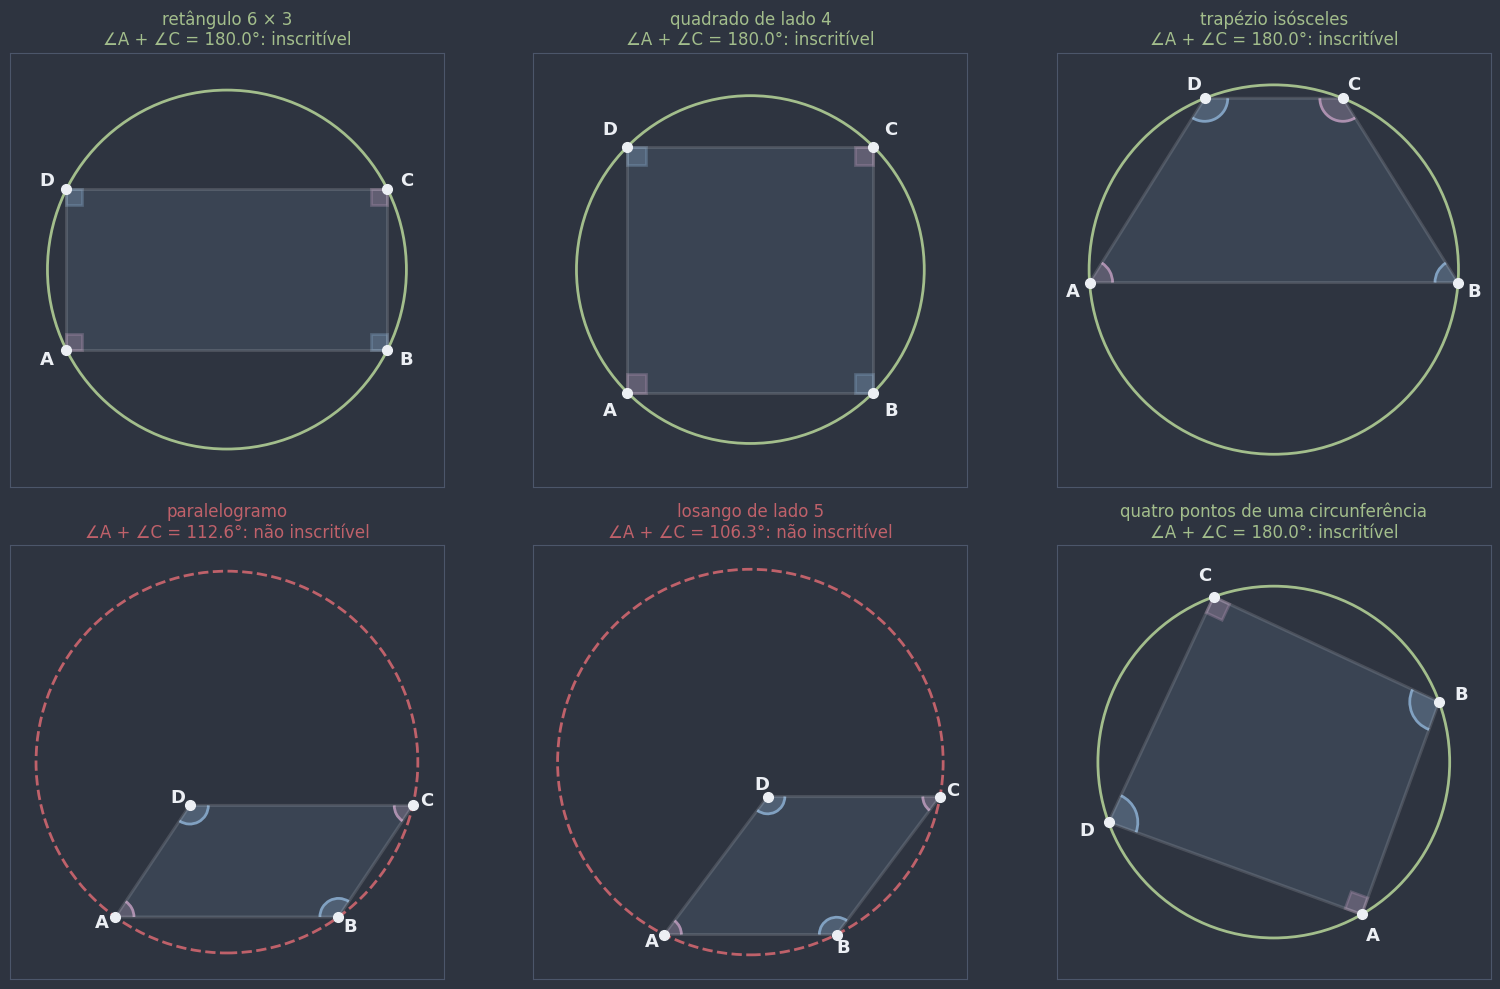

In [15]:
fig, eixos = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (nome, vertices) in zip(eixos.flat, exemplos_quadrilateros.items()):
    vertices = [np.array(v, dtype=float) for v in vertices]
    centro = circuncentro(*vertices[:3])
    raio = math.dist(centro, vertices[0])
    inscritivel = eh_inscritivel(*vertices)
    cor = COR_DESTAQUE if inscritivel else COR_ALERTA
    preparar_eixo(ax, [centro - raio, centro + raio] + vertices, margem=0.7)
    desenhar_circunferencia(ax, centro, raio, cor=cor, estilo="-" if inscritivel else "--", largura=2)
    ax.add_patch(Polygon(vertices, closed=True, facecolor=COR_SECUNDARIA, alpha=0.15, edgecolor=NORD_TEXTO, lw=2.2,
                         zorder=4))
    angulos = angulos_internos(vertices)
    for k, (V, letra) in enumerate(zip(vertices, "ABCD")):
        desenhar_arco(ax, V, vertices[k - 1], vertices[(k + 1) % 4], raio=0.5,
                      cor=COR_INSCRITO if k % 2 == 0 else COR_ARCO_2, marcar_reto=True)
        desenhar_ponto(ax, V, cor=NORD_TEXTO)
        rotular_fora(ax, V, letra, np.mean(vertices, axis=0), distancia=0.4, tamanho=13)
    ax.set_title(f"{nome}\n∠A + ∠C = {angulos[0] + angulos[2]:.1f}°: {'inscritível' if inscritivel else 'não inscritível'}",
                 color=cor, fontsize=12)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** os sliders `A`, `B`, `C` e `D` movem os quatro vértices sobre a circunferência (cada um numa faixa de direções, para o quadrilátero continuar convexo). Os ângulos $\hat{A}$ e $\hat{C}$ estão em roxo e $\hat{B}$ e $\hat{D}$, em azul. Mude a forma à vontade: as somas dos opostos não saem de 180°. Depois, use o slider `afastamento de D` para tirar o vértice $D$ da circunferência (valores maiores que 1 o empurram para fora; menores, para dentro) e veja as somas mudarem.

In [ ]:
def explorar_quadrilatero(A: int, B: int, C: int, D: int, afastamento_D: float) -> None:
    O_w, r_w = np.array([0.0, 0.0]), 3.0
    vertices = [ponto_na_circunferencia(O_w, r_w, a) for a in (A, B, C)]
    vertices.append(ponto_na_circunferencia(O_w, afastamento_D * r_w, D))
    angulos = angulos_internos(vertices)
    soma_AC, soma_BD = angulos[0] + angulos[2], angulos[1] + angulos[3]
    na_circunferencia = iguais(afastamento_D, 1)

    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(13.5, 6.4), gridspec_kw={"width_ratios": [1.15, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-1.3 * r_w, -1.3 * r_w), (1.3 * r_w, 1.3 * r_w)], margem=0.2)
    desenhar_circunferencia(ax, O_w, r_w, largura=2)
    ax.add_patch(Polygon(vertices, closed=True, facecolor=COR_SECUNDARIA, alpha=0.12, edgecolor=NORD_TEXTO, lw=2.2,
                         zorder=4))
    for k, (V, letra) in enumerate(zip(vertices, "ABCD")):
        cor = COR_INSCRITO if k % 2 == 0 else COR_ARCO_2
        desenhar_arco(ax, V, vertices[k - 1], vertices[(k + 1) % 4], raio=0.6, cor=cor, rotulo=f"{angulos[k]:.0f}°",
                      raio_rotulo=1.05, tamanho_fonte=11)
        desenhar_ponto(ax, V, cor=NORD_TEXTO)
        rotular_fora(ax, V, letra, O_w, distancia=0.4, tamanho=14)
    titulo = "ABCD inscrito: os ângulos opostos somam 180°" if na_circunferencia else "D fora da circunferência"
    ax.set_title(titulo, color=COR_DESTAQUE if na_circunferencia else COR_ALERTA, fontsize=13)
    itens = [
        (f"∠A = {angulos[0]:.1f}°   ∠B = {angulos[1]:.1f}°   ∠C = {angulos[2]:.1f}°   ∠D = {angulos[3]:.1f}°", True),
        (f"∠A + ∠C = {soma_AC:.1f}°", iguais(soma_AC, 180)),
        (f"∠B + ∠D = {soma_BD:.1f}°", iguais(soma_BD, 180)),
        (f"soma dos quatro ângulos = {sum(angulos):.1f}°", iguais(sum(angulos), 360)),
        ("D está sobre a circunferência", na_circunferencia),
    ]
    escrever_checklist(ax_lista, itens, "Quadrilátero inscritível?")
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_quadrilatero,
    A=widgets.IntSlider(value=30, min=0, max=80, step=5, description="A (°):"),
    B=widgets.IntSlider(value=105, min=90, max=170, step=5, description="B (°):"),
    C=widgets.IntSlider(value=225, min=180, max=260, step=5, description="C (°):"),
    D=widgets.IntSlider(value=290, min=270, max=350, step=5, description="D (°):"),
    afastamento_D=widgets.FloatSlider(value=1.0, min=0.8, max=1.25, step=0.05, description="afastamento de D:",
                                      style={"description_width": "initial"}),
);

interactive(children=(IntSlider(value=30, description='A (°):', max=80, step=5), IntSlider(value=105, descript…

📎 **Conexão — inscritível × circunscritível:** os dois nomes parecem iguais, mas os testes são bem diferentes.

| | **Inscritível** (esta seção) | **Circunscritível** ([`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb)) |
|---|---|---|
| Onde fica a circunferência | passa pelos **vértices** (o quadrilátero fica dentro dela) | tangente aos **lados** (ela fica dentro do quadrilátero) |
| Teste (quadrilátero convexo) | **ângulos** opostos suplementares: $\hat{A} + \hat{C} = 180°$ | soma dos **lados** opostos iguais (Pitot): $AB + CD = BC + DA$ |
| Exemplos | retângulo, quadrado, trapézio isósceles | losango, quadrado, pipa |

O quadrado está nas duas colunas. Um quadrilátero que é inscritível **e** circunscritível ao mesmo tempo se chama **bicêntrico** (tem duas circunferências especiais, cada uma com o seu centro).

⚠️ **Erro comum:** achar que **todo** quadrilátero é inscritível, como acontece com os triângulos (todo triângulo tem circunferência circunscrita). Com quatro vértices, não: o paralelogramo e o losango comuns são contraexemplos. Outro erro é trocar os nomes; o mnemônico de [`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb) continua valendo: **in**scrito → o polígono está **dentro** da circunferência, com os vértices **nela**; **circun**scrito → o polígono está **em volta**, com a circunferência dentro.

🎯 **Aplicação prática — o canteiro e a pista circular:** um paisagista quer contornar um canteiro de quatro lados com uma pista de caminhada circular que passe **exatamente pelos quatro cantos**. Antes de procurar o centro da pista, basta medir com um transferidor dois ângulos opostos do canteiro: se não somarem 180°, não existe pista possível. Na topografia, o mesmo teste serve para verificar se quatro marcos de um terreno estão sobre uma mesma circunferência, usando só os ângulos medidos em cada canto.

📖 **Leitura complementar:** [Quadrilátero cíclico](https://pt.wikipedia.org/wiki/Quadril%C3%A1tero_c%C3%ADclico)

**Pergunta de checagem:** um quadrilátero inscrito tem dois ângulos opostos de 70° e 110°. Os outros dois ângulos podem medir 80° e 90°? Por quê?

**Pergunta de checagem:** num quadrilátero inscrito $ABCD$, o ângulo interno $\hat{C}$ mede 102°. Quanto mede o ângulo externo no vértice $A$?

## 5. Ângulo de segmento

O ângulo inscrito tem dois lados que são **cordas**. E se um dos lados for **tangente** à circunferência?

📌 **Definição formal (ângulo de segmento):** um **ângulo de segmento** (ou **semi-inscrito**) é o ângulo formado por uma **corda** $\overline{AB}$ e pela **reta tangente** à circunferência numa das extremidades da corda (em $A$). O vértice é o ponto de tangência $A$, e o arco $\overset{\frown}{AB}$ que fica dentro do ângulo é o arco que ele enxerga.

📌 **Teorema:** o ângulo de segmento mede **a metade** do arco que ele enxerga, exatamente como o ângulo inscrito:

$$m(\text{ângulo de segmento}) = \frac{m(\overset{\frown}{AB})}{2}.$$

**Por quê?** Chame de $\theta$ o ângulo entre a tangente $t$ e a corda $\overline{AB}$ (para um arco menor que 180°, $\theta$ é agudo). Trace o diâmetro $\overline{AC}$ que sai do ponto de tangência.

1. A tangente é **perpendicular** ao raio no ponto de tangência ([`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb)), então o ângulo entre $t$ e o diâmetro $\overline{AC}$ é reto. Logo, $C\hat{A}B = 90° - \theta$.
2. O triângulo $ABC$ está inscrito numa semicircunferência (o lado $\overline{AC}$ é diâmetro), então ele é **retângulo em $B$** (seção 3, consequência 2). Os outros dois ângulos dele são complementares: $A\hat{C}B = 90° - C\hat{A}B = 90° - (90° - \theta) = \theta$.
3. Mas $A\hat{C}B$ é um **ângulo inscrito** que enxerga o arco $\overset{\frown}{AB}$. Então $\theta = A\hat{C}B = \dfrac{m(\overset{\frown}{AB})}{2}$.

Um bônus da demonstração: o **ângulo de segmento é congruente ao ângulo inscrito que enxerga o mesmo arco**.

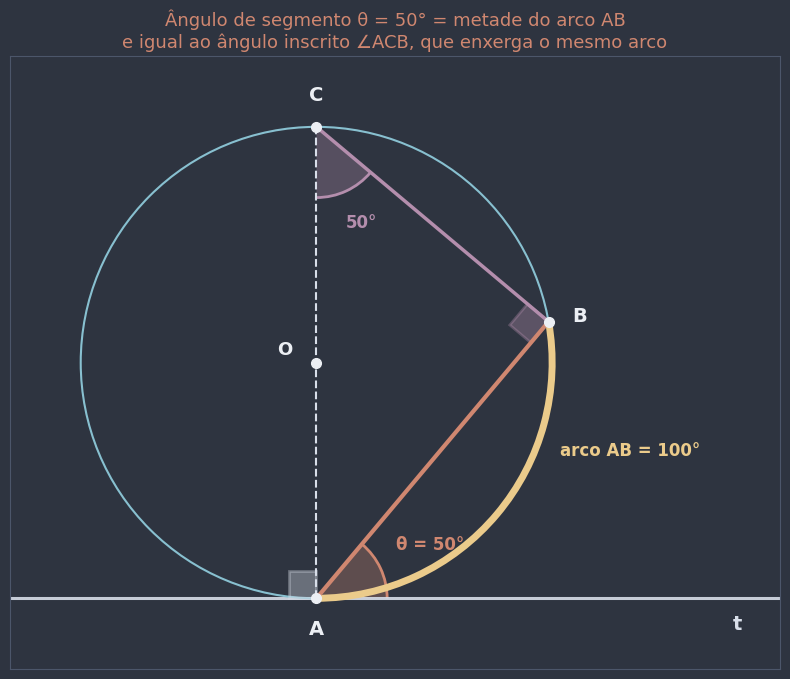

In [17]:
A = ponto_na_circunferencia(O, r, 270)  # o ponto de tangência, embaixo
C = ponto_na_circunferencia(O, r, 90)  # a outra ponta do diâmetro que sai de A
B = ponto_na_circunferencia(O, r, 270 + 100)  # o arco AB (de A até B, anti-horário) mede 100°
T = A + direcao(0)  # um ponto da tangente em A, do lado do arco AB

fig, ax = plt.subplots(figsize=(8, 7.6))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-r, -r), (r + 2.0, r)], margem=0.9)
desenhar_circunferencia(ax, O, r, largura=1.5)
desenhar_arco_da_circunferencia(ax, O, r, 270, 370)
desenhar_reta(ax, A, T, cor=COR_TANGENTE, largura=2.2)
ax.plot(*zip(A, C), color=NORD_TEXTO_SEC, lw=1.5, linestyle="--", zorder=3)
ax.plot(*zip(A, B), color=COR_SEGMENTO, lw=3, zorder=5)
ax.plot(*zip(C, B), color=COR_INSCRITO, lw=2.5, zorder=5)
theta = medir_angulo(A, T, B)
desenhar_arco(ax, A, T, B, raio=0.9, cor=COR_SEGMENTO, rotulo=f"θ = {theta:.0f}°", raio_rotulo=1.6, tamanho_fonte=12)
desenhar_arco(ax, C, A, B, raio=0.9, cor=COR_INSCRITO, rotulo=f"{medir_angulo(C, A, B):.0f}°", raio_rotulo=1.35,
              tamanho_fonte=12)
marcar_angulo_reto(ax, A, A - direcao(0), C, tamanho=0.35, cor=COR_TANGENTE)  # tangente ⊥ diâmetro
marcar_angulo_reto(ax, B, A, C, tamanho=0.35, cor=COR_INSCRITO)
for P, nome in ((A, "A"), (B, "B"), (C, "C")):
    desenhar_ponto(ax, P, cor=NORD_TEXTO)
    rotular_fora(ax, P, nome, O, distancia=0.4, tamanho=14)
desenhar_ponto(ax, O, "O", cor=COR_CENTRO, deslocamento=(-0.5, 0.1))
ax.text(r + 2.3, -r - 0.4, "t", color=COR_TANGENTE, fontsize=14, fontweight="bold")
ax.text(*ponto_na_circunferencia(O, r + 0.3, 340), "arco AB = 100°", color=COR_ARCO, fontsize=12,
        fontweight="bold", ha="left", va="center")
ax.set_title(f"Ângulo de segmento θ = {theta:.0f}° = metade do arco AB\n"
             "e igual ao ângulo inscrito ∠ACB, que enxerga o mesmo arco", color=COR_SEGMENTO, fontsize=13)
plt.tight_layout()
plt.show()

**Outra forma de ver (a ideia do limite):** pense num ângulo inscrito $X\hat{A}B$, com vértice em $A$, e deixe o ponto $X$ **deslizar** pelo arco $\overset{\frown}{AB}$ até encostar em $A$. A corda $\overline{AX}$ vai ficando cada vez mais curta e, no limite, vira a **tangente** em $A$. O ângulo inscrito vira o ângulo de segmento, e a regra "metade do arco" vai junto. A tabela mostra isso em números: o arco enxergado por $X\hat{A}B$ vai de $X$ até $B$, e cresce até o arco $\overset{\frown}{AB}$ inteiro (100°) quando $X$ chega em $A$.

In [18]:
linhas = []
for distancia_de_A in [60, 30, 10, 3, 1, 0.1, 0.01]:
    X = ponto_na_circunferencia(O, r, 270 + distancia_de_A)  # X desliza pelo arco AB, aproximando-se de A
    linhas.append({"distância de X até A (em graus de arco)": f"{distancia_de_A:g}°",
                   "ângulo inscrito XÂB (medido)": f"{medir_angulo(A, X, B):.4f}°",
                   "arco XB enxergado ÷ 2": f"{arco_enxergado(O, A, X, B) / 2:.4f}°"})
linhas.append({"distância de X até A (em graus de arco)": "X = A: o lado AX vira a tangente",
               "ângulo inscrito XÂB (medido)": f"{medir_angulo(A, T, B):.4f}° (entre a tangente e a corda)",
               "arco XB enxergado ÷ 2": "arco AB ÷ 2 = 50.0000°"})
display(pd.DataFrame(linhas).style.hide(axis="index"))

distância de X até A (em graus de arco),ângulo inscrito XÂB (medido),arco XB enxergado ÷ 2
60°,20.0000°,20.0000°
30°,35.0000°,35.0000°
10°,45.0000°,45.0000°
3°,48.5000°,48.5000°
1°,49.5000°,49.5000°
0.1°,49.9500°,49.9500°
0.01°,49.9950°,49.9950°
X = A: o lado AX vira a tangente,50.0000° (entre a tangente e a corda),arco AB ÷ 2 = 50.0000°


E se $X$ chegasse em $A$ pelo **outro** lado (pelo arco maior)? Aí o lado $\overline{AX}$ viraria a semirreta tangente que aponta para **fora** do arco $\overset{\frown}{AB}$, e o ângulo seria o suplemento: 180° − 50° = 130°. É o ângulo de segmento do **outro lado** da corda, que enxerga o arco maior (260°), e 260° ÷ 2 = 130°. A regra vale dos dois lados.

**No código:** com o ponto de tangência $A$ na direção $a$ (vista do centro), a tangente em $A$ aponta na direção $a + 90°$, que é para onde a circunferência "segue" no sentido anti-horário. O ângulo entre essa semirreta e a corda $\overline{AB}$ é o ângulo de segmento que enxerga o arco anti-horário de $A$ até $B$.

In [19]:
def angulo_de_segmento(O, posicao_A: float, posicao_B: float) -> float:
    """Ângulo entre a tangente em A (a semirreta que segue a circunferência no sentido anti-horário) e a corda AB.
    Ele enxerga o arco anti-horário de A até B. As posições são as direções de A e de B, vistas do centro."""
    A = ponto_na_circunferencia(O, 1, posicao_A)
    B = ponto_na_circunferencia(O, 1, posicao_B)
    return medir_angulo(A, A + direcao(posicao_A + 90), B)


linhas = []
for arco in [30, 60, 90, 120, 180, 240, 300]:
    segmento = angulo_de_segmento(O, 270, 270 + arco)
    linhas.append({"arco AB": f"{arco}°", "ângulo de segmento (medido)": f"{segmento:.4f}°",
                   "arco ÷ 2": f"{arco / 2:.4f}°", "tipo": "agudo" if segmento < 90 - 1e-9 else
                   ("reto: a corda é um diâmetro" if iguais(segmento, 90) else "obtuso")})
display(pd.DataFrame(linhas).style.hide(axis="index"))

arco AB,ângulo de segmento (medido),arco ÷ 2,tipo
30°,15.0000°,15.0000°,agudo
60°,30.0000°,30.0000°,agudo
90°,45.0000°,45.0000°,agudo
120°,60.0000°,60.0000°,agudo
180°,90.0000°,90.0000°,reto: a corda é um diâmetro
240°,120.0000°,120.0000°,obtuso
300°,150.0000°,150.0000°,obtuso


🕹️ **Widget interativo:** a reta cinza é a tangente $t$ no ponto $A$ (fixo, embaixo). O slider `arco AB` move o ponto $B$ e muda o arco enxergado. O ângulo de segmento (laranja) está sempre ao lado de um ângulo inscrito (roxo, com vértice em $C$) que enxerga o **mesmo** arco. Leve o arco até **180°**: a corda vira o diâmetro, e o ângulo de segmento vira o ângulo reto entre a tangente e o raio.

In [21]:
def explorar_segmento(arco_AB: int) -> None:
    O_w, r_w = np.array([0.0, 0.0]), 3.0
    A_w = ponto_na_circunferencia(O_w, r_w, 270)
    B_w = ponto_na_circunferencia(O_w, r_w, 270 + arco_AB)
    C_w = ponto_na_circunferencia(O_w, r_w, 270 + arco_AB + (360 - arco_AB) / 2)  # no meio do outro arco
    T_w = A_w + direcao(0)
    segmento = medir_angulo(A_w, T_w, B_w)
    inscrito = medir_angulo(C_w, A_w, B_w)
    diametro = arco_AB == 180

    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(13.5, 6.4), gridspec_kw={"width_ratios": [1.15, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-r_w, -r_w), (r_w, r_w)], margem=0.9)
    desenhar_circunferencia(ax, O_w, r_w, largura=1.5)
    desenhar_arco_da_circunferencia(ax, O_w, r_w, 270, 270 + arco_AB)
    desenhar_reta(ax, A_w, T_w, cor=COR_TANGENTE, largura=2.2)
    ax.plot(*zip(A_w, B_w), color=COR_SEGMENTO, lw=3, zorder=5)
    for P in (A_w, B_w):
        ax.plot(*zip(C_w, P), color=COR_INSCRITO, lw=2.2, zorder=5)
    desenhar_arco(ax, A_w, T_w, B_w, raio=0.8, cor=COR_SEGMENTO, rotulo=f"{segmento:.0f}°", raio_rotulo=1.45,
                  tamanho_fonte=12)
    desenhar_arco(ax, C_w, A_w, B_w, raio=0.7, cor=COR_INSCRITO, rotulo=f"{inscrito:.0f}°", raio_rotulo=1.25,
                  tamanho_fonte=12)
    if diametro:
        ax.plot(*zip(O_w, A_w), color=COR_CENTRAL, lw=3, zorder=6)
    for P, nome in ((A_w, "A"), (B_w, "B"), (C_w, "C")):
        desenhar_ponto(ax, P, cor=NORD_TEXTO)
        rotular_fora(ax, P, nome, O_w, distancia=0.4, tamanho=14)
    desenhar_ponto(ax, O_w, "O", cor=COR_CENTRO, deslocamento=(0.12, 0.15))
    ax.text(r_w + 0.5, -r_w - 0.4, "t", color=COR_TANGENTE, fontsize=14, fontweight="bold")
    ax.set_title("a corda AB é um diâmetro: tangente ⊥ diâmetro" if diametro
                 else f"ângulo de segmento {segmento:.1f}°  =  arco {arco_AB}° ÷ 2", color=COR_SEGMENTO, fontsize=13)
    itens = [
        (f"ângulo de segmento (tangente + corda) = {segmento:.2f}°", True),
        (f"arco AB = {arco_AB}°   →   arco ÷ 2 = {arco_AB / 2:.2f}°", iguais(segmento, arco_AB / 2)),
        (f"ângulo inscrito ∠ACB = {inscrito:.2f}°: igual ao de segmento", iguais(inscrito, segmento)),
        ("arco de 180°: a corda é diâmetro e o ângulo é reto", diametro),
    ]
    escrever_checklist(ax_lista, itens, "Ângulo de segmento")
    plt.tight_layout()
    plt.show()


widgets.interact(explorar_segmento,
                 arco_AB=widgets.IntSlider(value=100, min=10, max=350, step=10, description="arco AB:"));

interactive(children=(IntSlider(value=100, description='arco AB:', max=350, min=10, step=10), Output()), _dom_…

💡 **Dica:** o ângulo de segmento é o "elo perdido" entre o ângulo inscrito e a tangente. Sem ele, o caso em que **um dos lados é tangente** ficaria de fora da teoria. Na hora de resolver um problema, trate-o como um ângulo inscrito: ele vale metade do arco que fica **dentro** dele.

🎯 **Aplicação prática — direção de movimento numa pista circular:** um carro que percorre uma pista circular aponta, a cada instante, na direção da **tangente** à pista (é por isso que, se ele perder a aderência, sai pela tangente). Se o piloto, no ponto $A$, olha para um ponto $B$ mais à frente na pista, o ângulo entre a direção do carro e a linha de visada é um ângulo de segmento: metade do arco $\overset{\frown}{AB}$. Na navegação, o mesmo raciocínio relaciona o **rumo** de uma embarcação que contorna uma ilha em trajetória circular com a direção de um farol na mesma trajetória.

**Pergunta de checagem:** uma tangente e uma corda formam um ângulo de 38°. Quanto mede o arco determinado pela corda no interior desse ângulo?

**Pergunta de checagem:** por que o ângulo entre uma tangente e um **diâmetro** que sai do ponto de tangência tem que medir 90°? Responda de dois jeitos: pela propriedade da tangente e pelo teorema desta seção.

## 6. Ângulos excêntricos

Até aqui, o vértice esteve no **centro** (central) ou **sobre** a circunferência (inscrito e de segmento). Falta o vértice em qualquer **outro** ponto: dentro ou fora da circunferência. Esses ângulos se chamam **excêntricos** ("fora do centro"), e cada um enxerga **dois** arcos.

### Ângulo excêntrico interior

📌 **Definição formal:** duas cordas $\overline{AB}$ e $\overline{CD}$ se cortam num ponto $P$ **interior** à circunferência. O ângulo $A\hat{P}C$ enxerga o arco $\overset{\frown}{AC}$, e o seu oposto pelo vértice, $B\hat{P}D$ (que tem a mesma medida, [`0403a_angulos.ipynb`](0403a_angulos.ipynb)), enxerga o arco $\overset{\frown}{BD}$. A medida do ângulo é a **semissoma** desses dois arcos:

$$m(A\hat{P}C) = \frac{m(\overset{\frown}{AC}) + m(\overset{\frown}{BD})}{2}.$$

**Por quê?** Trace a corda auxiliar $\overline{BC}$. No triângulo $PBC$, o ângulo $A\hat{P}C$ é um **ângulo externo** (porque $A$, $P$ e $B$ estão alinhados), então ele é igual à soma dos dois internos não adjacentes:

$$m(A\hat{P}C) = m(A\hat{B}C) + m(D\hat{C}B).$$

Os dois são **ângulos inscritos**: $A\hat{B}C$ enxerga o arco $\overset{\frown}{AC}$, e $D\hat{C}B$ enxerga o arco $\overset{\frown}{BD}$. Cada um vale metade do seu arco, e a soma das metades é a semissoma.

### Ângulo excêntrico exterior

📌 **Definição formal:** o vértice $P$ está **fora** da circunferência, e os lados são duas **secantes** (ou uma secante e uma tangente, ou duas tangentes). Cada lado corta a circunferência num ponto mais próximo e num mais distante de $P$, e o ângulo "abraça" dois arcos: um **maior**, longe de $P$, e um **menor**, perto de $P$. A medida do ângulo é a **semidiferença** dos dois arcos:

$$m(\hat{P}) = \frac{m(\text{arco maior}) - m(\text{arco menor})}{2}.$$

A demonstração é parecida com a do interior, só que com uma **diferença** no lugar da soma; você vai montá-la passo a passo no Exercício Intermediário 4.

**O caso das duas tangentes.** Se os dois lados são tangentes à circunferência, nos pontos $T_1$ e $T_2$, os dois arcos são as duas partes da circunferência separadas por $T_1$ e $T_2$: o menor, de medida $\theta$, e o maior, de medida $360° - \theta$. Então

$$m(\hat{P}) = \frac{(360° - \theta) - \theta}{2} = 180° - \theta.$$

Dá para conferir isso de outro jeito, com [`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb): o quadrilátero $PT_1OT_2$ tem dois ângulos retos (as tangentes são perpendiculares aos raios), o ângulo central $T_1\hat{O}T_2 = \theta$ e o ângulo $\hat{P}$. A soma dos ângulos de um quadrilátero é 360°, então $90° + 90° + \theta + \hat{P} = 360°$, e $\hat{P} = 180° - \theta$. As duas contas concordam.

**No código:** a função `cruzamento_das_retas` encontra o ponto em que a reta $AB$ corta a reta $CD$ (é o `cruzamento` de [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb), recebendo dois pontos de cada reta). A tabela compara, nos três casos, o ângulo medido pelo transferidor com a regra.

In [22]:
def cruzamento_das_retas(A, B, C, D):
    """Ponto em que a reta AB corta a reta CD (None se forem paralelas)."""
    return cruzamento(A, direcao_de(A, B), C, direcao_de(C, D))


def ponto_mais_proximo(P, candidatos) -> np.ndarray:
    """Dos pontos `candidatos`, o que está mais perto de P."""
    return min(candidatos, key=lambda X: math.dist(P, X))


# 1) Interior: as cordas AB e CD se cortam em P
A_i, B_i, C_i, D_i = (ponto_na_circunferencia(O, r, a) for a in (100, 290, 20, 200))
P_i = cruzamento_das_retas(A_i, B_i, C_i, D_i)
arco_AC, arco_BD = medir_angulo(O, A_i, C_i), medir_angulo(O, B_i, D_i)

# 2) Exterior: as secantes PB e PD, com P fora; A e C são os pontos mais próximos de P
P_e = np.array([0.0, -6.0])
B_e, D_e = ponto_na_circunferencia(O, r, 60), ponto_na_circunferencia(O, r, 120)
A_e = ponto_mais_proximo(P_e, intersecao_reta_circunferencia(O, r, P_e, B_e))
C_e = ponto_mais_proximo(P_e, intersecao_reta_circunferencia(O, r, P_e, D_e))
arco_maior_e, arco_menor_e = medir_angulo(O, B_e, D_e), medir_angulo(O, A_e, C_e)

# 3) Duas tangentes saindo do mesmo P: cada ponto de tangência faz um ângulo de 90° entre o raio e a tangente.
# O ângulo entre OP e cada raio OT é o ângulo cujo cosseno é r/OP (acos vem da Trigonometria; só constrói a figura)
afastamento = math.degrees(math.acos(r / math.dist(O, P_e)))
T1, T2 = (ponto_na_circunferencia(O, r, direcao_de(O, P_e) + s * afastamento) for s in (-1, 1))
theta = medir_angulo(O, T1, T2)

display(pd.DataFrame([
    {"caso": "interior (duas cordas)", "ângulo medido": f"{medir_angulo(P_i, A_i, C_i):.4f}°",
     "arcos": f"AC = {arco_AC:.1f}°, BD = {arco_BD:.1f}°", "regra": "(AC + BD) ÷ 2",
     "valor da regra": f"{(arco_AC + arco_BD) / 2:.4f}°"},
    {"caso": "exterior (duas secantes)", "ângulo medido": f"{medir_angulo(P_e, B_e, D_e):.4f}°",
     "arcos": f"BD = {arco_maior_e:.1f}°, AC = {arco_menor_e:.1f}°", "regra": "(BD − AC) ÷ 2",
     "valor da regra": f"{(arco_maior_e - arco_menor_e) / 2:.4f}°"},
    {"caso": "exterior (duas tangentes)", "ângulo medido": f"{medir_angulo(P_e, T1, T2):.4f}°",
     "arcos": f"θ = {theta:.1f}°, 360° − θ = {360 - theta:.1f}°", "regra": "180° − θ",
     "valor da regra": f"{180 - theta:.4f}°"},
]).style.hide(axis="index"))

caso,ângulo medido,arcos,regra,valor da regra
interior (duas cordas),85.0000°,"AC = 80.0°, BD = 90.0°",(AC + BD) ÷ 2,85.0000°
exterior (duas secantes),19.7922°,"BD = 60.0°, AC = 20.4°",(BD − AC) ÷ 2,19.7922°
exterior (duas tangentes),60.0000°,"θ = 120.0°, 360° − θ = 240.0°",180° − θ,60.0000°


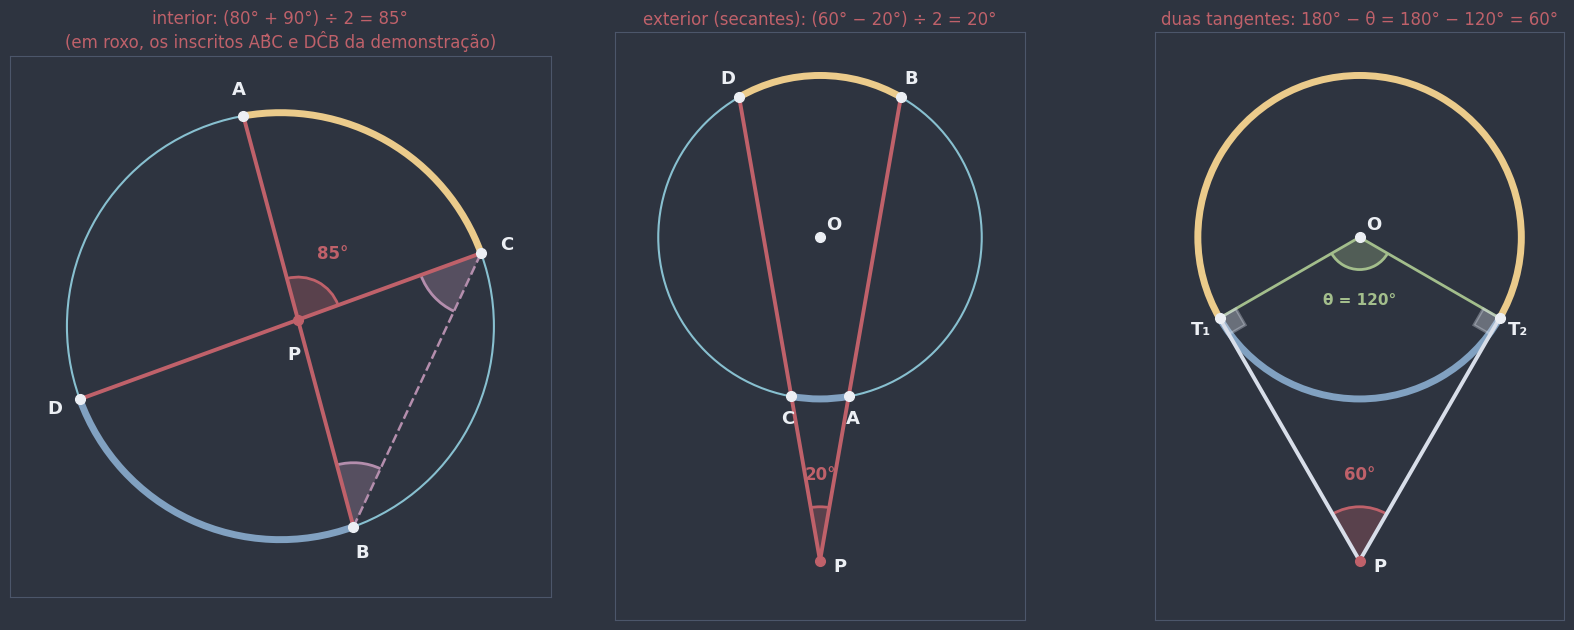

In [23]:
fig, eixos = plt.subplots(1, 3, figsize=(16.5, 6.4))
fig.patch.set_facecolor(NORD_FUNDO)

# 1) Interior, com a corda auxiliar BC da demonstração
ax = eixos[0]
preparar_eixo(ax, [(-r, -r), (r, r)], margem=0.8)
desenhar_circunferencia(ax, O, r, largura=1.5)
desenhar_arco_menor(ax, O, r, A_i, C_i, cor=COR_ARCO)
desenhar_arco_menor(ax, O, r, B_i, D_i, cor=COR_ARCO_2)
for X, Y in ((A_i, B_i), (C_i, D_i)):
    ax.plot(*zip(X, Y), color=COR_EXCENTRICO, lw=2.8, zorder=5)
ax.plot(*zip(B_i, C_i), color=COR_INSCRITO, lw=1.8, linestyle="--", zorder=4)
desenhar_arco(ax, P_i, A_i, C_i, raio=0.6, cor=COR_EXCENTRICO, rotulo=f"{medir_angulo(P_i, A_i, C_i):.0f}°",
              raio_rotulo=1.05, tamanho_fonte=12)
desenhar_arco(ax, B_i, A_i, C_i, raio=0.9, cor=COR_INSCRITO)
desenhar_arco(ax, C_i, D_i, B_i, raio=0.9, cor=COR_INSCRITO)
for X, nome in ((A_i, "A"), (B_i, "B"), (C_i, "C"), (D_i, "D")):
    desenhar_ponto(ax, X, cor=NORD_TEXTO)
    rotular_fora(ax, X, nome, O, distancia=0.38, tamanho=13)
desenhar_ponto(ax, P_i, "P", cor=COR_EXCENTRICO, deslocamento=(-0.15, -0.55))
ax.set_title(f"interior: ({arco_AC:.0f}° + {arco_BD:.0f}°) ÷ 2 = {(arco_AC + arco_BD) / 2:.0f}°\n"
             "(em roxo, os inscritos AB̂C e DĈB da demonstração)", color=COR_EXCENTRICO, fontsize=12)

# 2) Exterior com duas secantes  e  3) exterior com duas tangentes
for ax, (X1, X2, titulo) in zip(eixos[1:], (
        ((B_e, D_e), (A_e, C_e), f"exterior (secantes): ({arco_maior_e:.0f}° − {arco_menor_e:.0f}°) ÷ 2 = "
                                 f"{(arco_maior_e - arco_menor_e) / 2:.0f}°"),
        ((T1, T2), None, f"duas tangentes: 180° − θ = 180° − {theta:.0f}° = {180 - theta:.0f}°"))):
    preparar_eixo(ax, [(-r, -6.3), (r, r)], margem=0.8)
    desenhar_circunferencia(ax, O, r, largura=1.5)
    if X2 is None:  # tangentes: o arco menor θ e o arco maior
        desenhar_arco_menor(ax, O, r, T1, T2, cor=COR_ARCO_2)
        desenhar_arco_da_circunferencia(ax, O, r, direcao_de(O, T2), direcao_de(O, T1), cor=COR_ARCO)
        for T in (T1, T2):
            ax.plot(*zip(O, T), color=COR_CENTRAL, lw=2, zorder=4)
            marcar_angulo_reto(ax, T, O, P_e, tamanho=0.35, cor=COR_TANGENTE)
        desenhar_arco(ax, O, T1, T2, raio=0.6, cor=COR_CENTRAL, rotulo=f"θ = {theta:.0f}°", raio_rotulo=1.15,
                      tamanho_fonte=11)
        pontos = [(T1, "T₁"), (T2, "T₂")]
    else:
        desenhar_arco_menor(ax, O, r, *X1, cor=COR_ARCO)
        desenhar_arco_menor(ax, O, r, *X2, cor=COR_ARCO_2)
        pontos = [(X2[0], "A"), (X1[0], "B"), (X2[1], "C"), (X1[1], "D")]
    for X in X1:
        ax.plot(*zip(P_e, X), color=COR_EXCENTRICO if X2 is not None else COR_TANGENTE, lw=2.8, zorder=5)
    angulo_P = medir_angulo(P_e, *X1)
    desenhar_arco(ax, P_e, *X1, raio=1.0, cor=COR_EXCENTRICO, rotulo=f"{angulo_P:.0f}°", raio_rotulo=1.6,
                  tamanho_fonte=12)
    for X, nome in pontos:
        desenhar_ponto(ax, X, cor=NORD_TEXTO)
        rotular_fora(ax, X, nome, O, distancia=0.4, tamanho=13)
    desenhar_ponto(ax, P_e, "P", cor=COR_EXCENTRICO, deslocamento=(0.25, -0.2))
    desenhar_ponto(ax, O, "O", cor=COR_CENTRO, deslocamento=(0.12, 0.15))
    ax.set_title(titulo, color=COR_EXCENTRICO, fontsize=12)
plt.tight_layout()
plt.show()

### Todos os casos numa regra só

Os ângulos deste notebook formam uma família. Imagine um ângulo de **abertura variável**, com o vértice $P$ andando numa linha reta, do centro da circunferência para fora, e com os lados sempre passando por dois pontos fixos $X$ e $Y$ da circunferência. O ângulo $X\hat{P}Y$ enxerga o arco $\overset{\frown}{XY}$ (amarelo) e, do outro lado, um segundo arco (azul), que muda conforme $P$ anda:

- com $P$ **no centro**, o segundo arco é igual ao primeiro, e a semissoma dá o **arco inteiro**: é o ângulo **central**;
- com $P$ **dentro**, vale a **semissoma** dos dois arcos;
- com $P$ **sobre** a circunferência, o segundo arco encolhe até **sumir** (mede 0°), e a semissoma vira **metade do arco**: é o ângulo **inscrito**;
- com $P$ **fora**, o segundo arco reaparece, agora do **mesmo lado** do primeiro, e vale a **semidiferença**.

🕹️ **Widget interativo:** o slider `altura de P` move o vértice pela vertical que passa pelo centro (de 0, o centro, até −7; a circunferência tem raio 2, então $P$ a cruza em −2). O slider `arco XY` muda o arco amarelo. O painel mostra qual regra vale em cada região e compara o valor da regra com o ângulo medido pelo transferidor.

In [ ]:
def explorar_excentrico(altura_P: float, arco_XY: int) -> None:
    O_w, r_w = np.array([0.0, 0.0]), 2.0
    P_w = np.array([0.0, altura_P])
    X_w = ponto_na_circunferencia(O_w, r_w, 90 - arco_XY / 2)
    Y_w = ponto_na_circunferencia(O_w, r_w, 90 + arco_XY / 2)
    # A outra interseção de cada lado com a circunferência (a que fica longe de X e de Y)
    X2 = max(intersecao_reta_circunferencia(O_w, r_w, P_w, X_w), key=lambda Z: math.dist(Z, X_w))
    Y2 = max(intersecao_reta_circunferencia(O_w, r_w, P_w, Y_w), key=lambda Z: math.dist(Z, Y_w))
    arco_2 = medir_angulo(O_w, X2, Y2) if math.dist(X2, Y2) > 1e-6 else 0.0
    medido = medir_angulo(P_w, X_w, Y_w)
    OP = math.dist(O_w, P_w)
    if OP < 1e-9:
        regiao, regra, cor = "centro", arco_XY, COR_CENTRAL
    elif iguais(OP, r_w):
        regiao, regra, cor = "sobre", arco_XY / 2, COR_INSCRITO
    elif OP < r_w:
        regiao, regra, cor = "dentro", (arco_XY + arco_2) / 2, COR_EXCENTRICO
    else:
        regiao, regra, cor = "fora", (arco_XY - arco_2) / 2, COR_EXCENTRICO

    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(13.5, 6.6), gridspec_kw={"width_ratios": [1, 1.1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-3.6, -7.3), (3.6, 2.6)], margem=0)
    desenhar_circunferencia(ax, O_w, r_w, largura=1.8)
    desenhar_arco_menor(ax, O_w, r_w, X_w, Y_w, cor=COR_ARCO)
    if arco_2 > 0:
        desenhar_arco_menor(ax, O_w, r_w, X2, Y2, cor=COR_ARCO_2)
    ax.plot([0, 0], [-7.2, 0], color=NORD_LINHA, lw=1, linestyle=":", zorder=1)  # o caminho de P
    for Z, Z2 in ((X_w, X2), (Y_w, Y2)):
        ax.plot(*zip(P_w, Z), color=cor, lw=2.6, zorder=5)
        if regiao in ("centro", "dentro"):
            ax.plot(*zip(P_w, Z2), color=cor, lw=2.6, zorder=5)
    desenhar_arco(ax, P_w, X_w, Y_w, raio=0.5, cor=cor, rotulo=f"{medido:.1f}°", raio_rotulo=0.95,
                  tamanho_fonte=11)
    for Z, nome in ((X_w, "X"), (Y_w, "Y")):
        desenhar_ponto(ax, Z, cor=NORD_TEXTO)
        rotular_fora(ax, Z, nome, O_w, distancia=0.35, tamanho=13)
    ax.plot(*O_w, "+", color=COR_CENTRO, markersize=10, zorder=6)
    desenhar_ponto(ax, P_w, "P", cor=cor, deslocamento=(0.2, -0.35))
    ax.set_title(f"ângulo XPY = {medido:.1f}°", color=cor, fontsize=14)
    itens = [
        (f"arco XY (amarelo) = {arco_XY}°     segundo arco (azul) = {arco_2:.1f}°", True),
        (f"P no centro  →  ângulo = arco XY = {arco_XY}°", regiao == "centro"),
        (f"P dentro  →  ângulo = ({arco_XY}° + {arco_2:.1f}°) ÷ 2", regiao == "dentro"),
        (f"P sobre a circunferência  →  ângulo = {arco_XY}° ÷ 2", regiao == "sobre"),
        (f"P fora  →  ângulo = ({arco_XY}° − {arco_2:.1f}°) ÷ 2", regiao == "fora"),
        (f"regra: {regra:.2f}°     transferidor: {medido:.2f}°", iguais(regra, medido)),
    ]
    escrever_checklist(ax_lista, itens, "Qual regra vale?")
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_excentrico,
    altura_P=widgets.FloatSlider(value=-1.5, min=-7.0, max=0.0, step=0.25, description="altura de P:"),
    arco_XY=widgets.IntSlider(value=80, min=20, max=140, step=10, description="arco XY:"),
);

interactive(children=(FloatSlider(value=-1.5, description='altura de P:', max=0.0, min=-7.0, step=0.25), IntSl…

💡 **Dica de síntese:** a regra "metade do arco" do ângulo inscrito é o meio do caminho. Puxando o vértice para **dentro**, o segundo arco aparece do lado **oposto** e **soma**; empurrando para **fora**, ele aparece do **mesmo** lado e **subtrai**. No centro, a semissoma de dois arcos iguais é o próprio arco.

⚠️ **Erro comum:** trocar semissoma por semidiferença. **Mnemônico:** **dentro → soma** (o vértice está no meio, e os dois arcos ficam um de cada lado, "somando forças"); **fora → diferença** (os dois arcos ficam do mesmo lado e "competem" pelo mesmo ângulo: o de longe abre, o de perto fecha). Outro tropeço comum: no ângulo exterior, usar um arco que **não** está entre os lados do ângulo; os dois arcos da regra são os que ficam **dentro** da abertura.

🎯 **Aplicação prática — o planeta visto de um satélite:** de um satélite em órbita, a Terra aparece entre duas linhas de visada **tangentes** à superfície (o horizonte). O ângulo sob o qual o satélite vê a Terra é um ângulo excêntrico exterior com duas tangentes: $180° - \theta$, em que $\theta$ é o arco da superfície que o satélite consegue enxergar. Quanto mais alto o satélite, menor o ângulo e maior o arco $\theta$ visível, até o limite de quase meia Terra (180°) para um satélite muito distante. É esse arco que define a **área de cobertura** de satélites de comunicação e de GPS.

**Pergunta de checagem:** duas cordas se cortam dentro de uma circunferência; um dos ângulos formados enxerga um arco de 70°, e o seu oposto pelo vértice enxerga um arco de 50°. Quanto mede cada um desses dois ângulos? E os outros dois ângulos formados pelas cordas?

**Pergunta de checagem:** de um ponto exterior, duas secantes enxergam arcos de 100° e 40°. Quanto mede o ângulo entre elas? E se, do mesmo tipo de ponto, saírem duas **tangentes** cujos pontos de tangência determinam um arco menor de 140°?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| **Medida de um arco** | em graus, é a medida do ângulo central correspondente; circunferência = 360°, semicircunferência = 180°; **não depende do raio** |
| **Arcos congruentes** | mesma medida **e** mesmo raio (ou mesma circunferência) |
| **Adição de arcos** | arcos consecutivos: $m(\overset{\frown}{AC}) = m(\overset{\frown}{AB}) + m(\overset{\frown}{BC})$ |
| **Arcos e cordas** | arcos congruentes ⇔ cordas congruentes; entre arcos menores que 180°, maior arco ⇔ maior corda |
| ⚠️ **Medida × comprimento** | medida em graus (independe do raio) ≠ comprimento em cm (depende do raio; 📌 Polígonos Regulares e Comprimento da Circunferência) |
| **Ângulo central** | vértice no centro; $m(A\hat{O}B) = m(\overset{\frown}{AB})$ |
| **Ângulo inscrito** | vértice na circunferência, lados são cordas; $m = \dfrac{\text{arco}}{2}$ (metade do central) |
| **Consequências** | mesmo arco ⇒ mesmo ângulo inscrito; ângulo que enxerga uma semicircunferência = **90°**; circuncentro do triângulo retângulo = ponto médio da hipotenusa |
| **Arco capaz** | os pontos que enxergam $\overline{AB}$ sob o ângulo $\alpha$ formam dois arcos de circunferência por $A$ e $B$ (arco capaz de 90° = circunferência de diâmetro $\overline{AB}$) |
| **Quadrilátero inscritível** | vértices numa circunferência ⇔ (se convexo) ângulos opostos **suplementares**; ângulo externo = interno oposto. Sim: retângulo, quadrado, trapézio isósceles. Não: paralelogramo e losango comuns |
| **Ângulo de segmento** | tangente + corda, vértice no ponto de tangência; $m = \dfrac{\text{arco}}{2}$ (igual ao inscrito do mesmo arco) |

**Onde está o vértice decide a regra:**

| Posição do vértice | Fórmula | Exemplo |
|---|---|---|
| no **centro** | arco inteiro | ângulo central |
| **na** circunferência | $\dfrac{\text{arco}}{2}$ | ângulo inscrito e ângulo de segmento |
| **dentro** (duas cordas) | $\dfrac{\text{arco}_1 + \text{arco}_2}{2}$ | semissoma |
| **fora** (secantes ou tangentes) | $\dfrac{\text{arco maior} - \text{arco menor}}{2}$ | semidiferença; duas tangentes: $180° - \theta$ |

**Mnemônico:** **dentro → soma; fora → diferença.**

**Contraste:** **inscritível** (vértices na circunferência; ângulos opostos suplementares) × **circunscritível** (lados tangentes à circunferência; Pitot: $AB + CD = BC + DA$).

As figuras abaixo repetem as cores usadas no notebook inteiro: central verde, inscrito roxo, de segmento laranja, excêntricos vermelhos; arco enxergado amarelo e segundo arco azul.

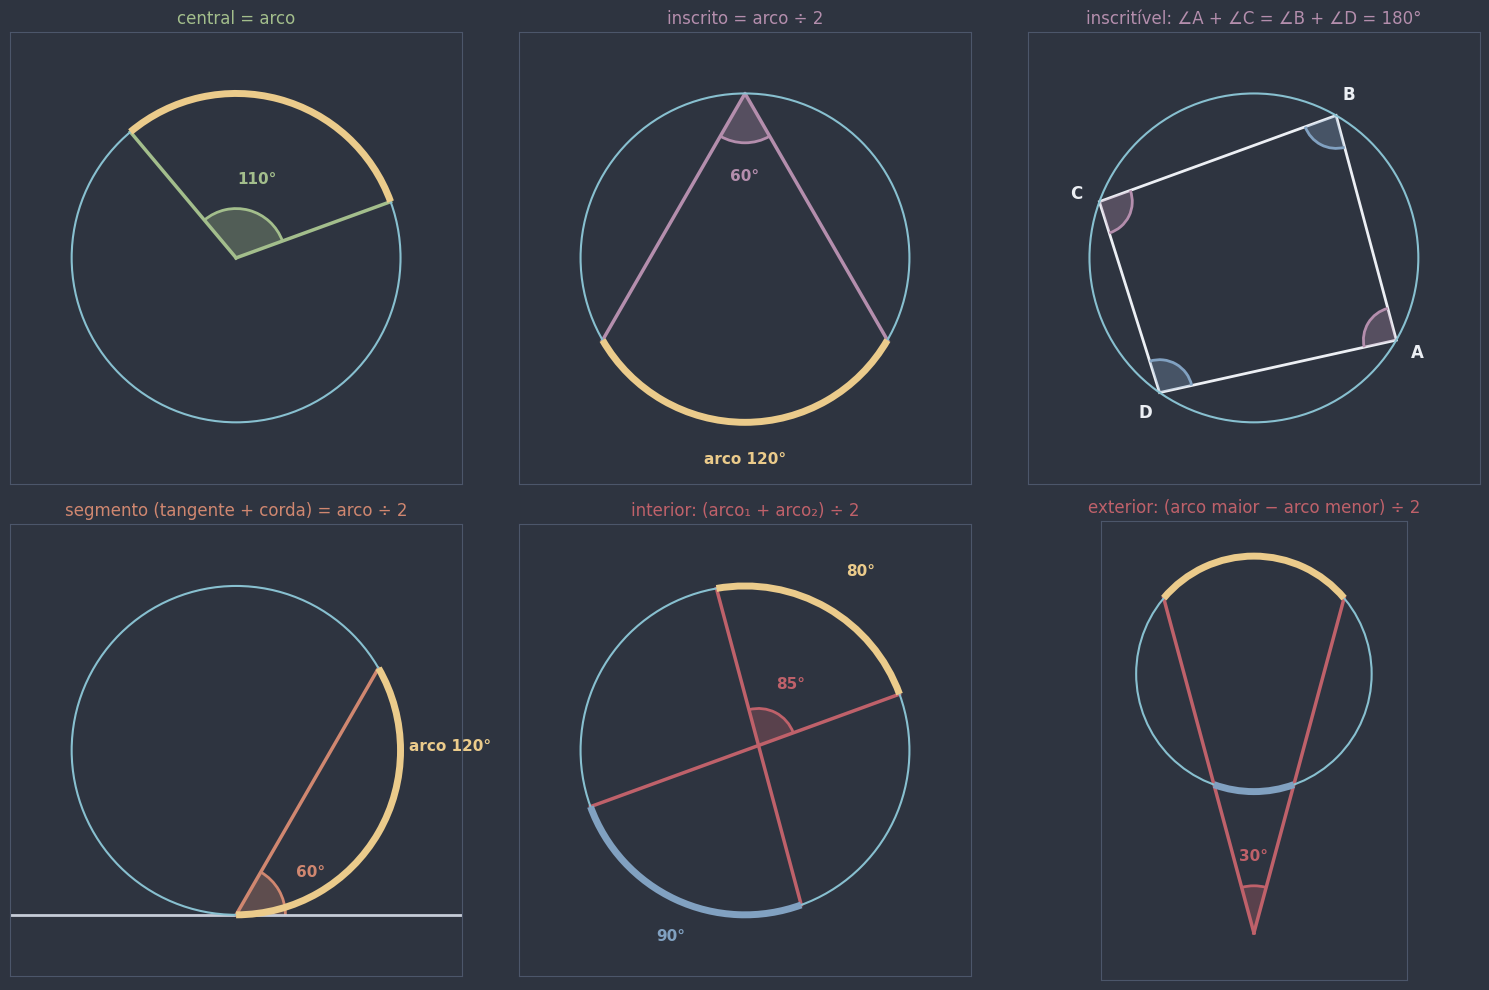

In [25]:
def cartao(ax, titulo: str, cor: str) -> None:
    """Prepara um quadrinho do cheat sheet: circunferência de raio 2 centrada na origem."""
    preparar_eixo(ax, [(-2, -2), (2, 2)], margem=0.75)
    desenhar_circunferencia(ax, (0, 0), 2, largura=1.5)
    ax.set_title(titulo, color=cor, fontsize=12)


O_c, r_c = np.array([0.0, 0.0]), 2.0
fig, eixos = plt.subplots(2, 3, figsize=(15, 10))
fig.patch.set_facecolor(NORD_FUNDO)

# Central
ax = eixos[0, 0]
cartao(ax, "central = arco", COR_CENTRAL)
A_c, B_c = extremidades_do_arco(O_c, r_c, 20, 110)
desenhar_arco_da_circunferencia(ax, O_c, r_c, 20, 130)
for P in (A_c, B_c):
    ax.plot(*zip(O_c, P), color=COR_CENTRAL, lw=2.5)
desenhar_setor(ax, O_c, 20, 110, raio=0.6, cor=COR_CENTRAL, rotulo="110°", raio_rotulo=1.0)

# Inscrito
ax = eixos[0, 1]
cartao(ax, "inscrito = arco ÷ 2", COR_INSCRITO)
A_c, B_c, V_c = (ponto_na_circunferencia(O_c, r_c, a) for a in (210, 330, 90))
desenhar_arco_da_circunferencia(ax, O_c, r_c, 210, 330)
ax.plot(*zip(A_c, V_c, B_c), color=COR_INSCRITO, lw=2.5)
desenhar_arco(ax, V_c, A_c, B_c, raio=0.6, cor=COR_INSCRITO, rotulo="60°", raio_rotulo=1.0)
ax.text(0, -2.5, "arco 120°", color=COR_ARCO, fontsize=11, ha="center", fontweight="bold")

# Quadrilátero inscritível
ax = eixos[0, 2]
cartao(ax, "inscritível: ∠A + ∠C = ∠B + ∠D = 180°", COR_INSCRITO)
vertices_c = [ponto_na_circunferencia(O_c, r_c, a) for a in (330, 60, 160, 235)]
ax.add_patch(Polygon(vertices_c, closed=True, fill=False, edgecolor=NORD_TEXTO, lw=2))
for k, V in enumerate(vertices_c):
    desenhar_arco(ax, V, vertices_c[k - 1], vertices_c[(k + 1) % 4], raio=0.4,
                  cor=COR_INSCRITO if k % 2 == 0 else COR_ARCO_2)
    rotular_fora(ax, V, "ABCD"[k], O_c, distancia=0.3, tamanho=12)

# Segmento
ax = eixos[1, 0]
cartao(ax, "segmento (tangente + corda) = arco ÷ 2", COR_SEGMENTO)
A_c, B_c = ponto_na_circunferencia(O_c, r_c, 270), ponto_na_circunferencia(O_c, r_c, 30)
desenhar_arco_da_circunferencia(ax, O_c, r_c, 270, 30)
desenhar_reta(ax, A_c, A_c + direcao(0), cor=COR_TANGENTE)
ax.plot(*zip(A_c, B_c), color=COR_SEGMENTO, lw=2.5)
desenhar_arco(ax, A_c, A_c + direcao(0), B_c, raio=0.6, cor=COR_SEGMENTO, rotulo="60°", raio_rotulo=1.05)
ax.text(2.1, 0.0, "arco 120°", color=COR_ARCO, fontsize=11, fontweight="bold")

# Interior
ax = eixos[1, 1]
cartao(ax, "interior: (arco₁ + arco₂) ÷ 2", COR_EXCENTRICO)
A_c, B_c, C_c, D_c = (ponto_na_circunferencia(O_c, r_c, a) for a in (100, 290, 20, 200))
P_c = cruzamento_das_retas(A_c, B_c, C_c, D_c)
desenhar_arco_menor(ax, O_c, r_c, A_c, C_c)
desenhar_arco_menor(ax, O_c, r_c, B_c, D_c, cor=COR_ARCO_2)
ax.plot(*zip(A_c, B_c), color=COR_EXCENTRICO, lw=2.5)
ax.plot(*zip(C_c, D_c), color=COR_EXCENTRICO, lw=2.5)
desenhar_arco(ax, P_c, A_c, C_c, raio=0.45, cor=COR_EXCENTRICO, rotulo=f"{medir_angulo(P_c, A_c, C_c):.0f}°",
              raio_rotulo=0.85)
ax.text(*ponto_na_circunferencia(O_c, r_c + 0.45, 60), "80°", color=COR_ARCO, fontsize=11, fontweight="bold")
ax.text(*ponto_na_circunferencia(O_c, r_c + 0.55, 245), "90°", color=COR_ARCO_2, fontsize=11, fontweight="bold")

# Exterior
ax = eixos[1, 2]
preparar_eixo(ax, [(-2, -4.6), (2, 2)], margem=0.6)
desenhar_circunferencia(ax, O_c, r_c, largura=1.5)
ax.set_title("exterior: (arco maior − arco menor) ÷ 2", color=COR_EXCENTRICO, fontsize=12)
P_c = np.array([0.0, -4.4])
B_c, D_c = ponto_na_circunferencia(O_c, r_c, 40), ponto_na_circunferencia(O_c, r_c, 140)
A_c = ponto_mais_proximo(P_c, intersecao_reta_circunferencia(O_c, r_c, P_c, B_c))
C_c = ponto_mais_proximo(P_c, intersecao_reta_circunferencia(O_c, r_c, P_c, D_c))
desenhar_arco_menor(ax, O_c, r_c, B_c, D_c)
desenhar_arco_menor(ax, O_c, r_c, A_c, C_c, cor=COR_ARCO_2)
for X in (B_c, D_c):
    ax.plot(*zip(P_c, X), color=COR_EXCENTRICO, lw=2.5)
desenhar_arco(ax, P_c, B_c, D_c, raio=0.8, cor=COR_EXCENTRICO, rotulo=f"{medir_angulo(P_c, B_c, D_c):.0f}°",
              raio_rotulo=1.3)
plt.tight_layout()
plt.show()

## Exercícios

**Básico**
1. Ângulo central, arco e ângulo inscrito.
2. Quadrilátero inscrito e ângulo de segmento.

**Intermediário**

3. As regras deste notebook como funções, e uma verificação numérica do teorema do ângulo inscrito.
4. Caça-ângulos: encadeando as regras (e a demonstração do ângulo excêntrico exterior).
5. Um teste de quadrilátero inscritível pelas coordenadas dos vértices.

**Desafio**

6. O pentagrama revisitado.
7. Ângulo reto sem régua: o arco capaz de 90°.

Gabarito completo com resolução comentada em [`0413b_angulos_na_circunferencia_gabarito.ipynb`](0413b_angulos_na_circunferencia_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: central, arco e inscrito.
# (a) Um ângulo central mede 80°. Guarde em `arco_ex1a` a medida do arco correspondente, em `arco_maior_ex1a` a
#     medida do outro arco (o arco maior) e em `inscrito_ex1a` a medida de um ângulo inscrito que enxerga o mesmo
#     arco de 80°.
# (b) Um ângulo inscrito mede 35°. Guarde em `arco_ex1b` a medida do arco que ele enxerga e em `central_ex1b` a
#     medida do ângulo central correspondente a esse arco.
# (c) AB é um diâmetro e P é um ponto da circunferência, diferente de A e de B. Guarde em `angulo_APB_ex1c` a
#     medida do ângulo APB.
# (d) Um ângulo inscrito enxerga um arco de 250°. Guarde a medida dele em `inscrito_ex1d`.
arco_ex1a = ...
arco_maior_ex1a = ...
inscrito_ex1a = ...
arco_ex1b = ...
central_ex1b = ...
angulo_APB_ex1c = ...
inscrito_ex1d = ...

print(arco_ex1a, arco_maior_ex1a, inscrito_ex1a, arco_ex1b, central_ex1b, angulo_APB_ex1c, inscrito_ex1d)

In [ ]:
# Verificação
assert arco_ex1a is not ... and math.isclose(arco_ex1a, 80), (
    "Tente de novo, revise: o ângulo central e o arco correspondente têm a mesma medida (seção 2 - Ângulo central)."
)
assert arco_maior_ex1a is not ... and math.isclose(arco_maior_ex1a, 280), (
    "Tente de novo, revise: os dois arcos determinados pelos mesmos pontos somam 360° (seção 1 - Arcos: medida, "
    "congruência, adição e desigualdade)."
)
assert inscrito_ex1a is not ... and math.isclose(inscrito_ex1a, 40), (
    "Tente de novo, revise: o ângulo inscrito é a metade do arco que ele enxerga (seção 3 - Ângulo inscrito)."
)
assert arco_ex1b is not ... and math.isclose(arco_ex1b, 70) and central_ex1b is not ... and \
    math.isclose(central_ex1b, 70), (
    "Tente de novo, revise: se o inscrito é a metade do arco, o arco é o DOBRO do inscrito, e o central é igual ao "
    "arco (seção 3 - Ângulo inscrito)."
)
assert angulo_APB_ex1c is not ... and math.isclose(angulo_APB_ex1c, 90), (
    "Tente de novo, revise: um ângulo inscrito que enxerga uma semicircunferência (180°) é reto (seção 3 - Ângulo "
    "inscrito)."
)
assert inscrito_ex1d is not ... and math.isclose(inscrito_ex1d, 125), (
    "Tente de novo, revise: a regra vale também para arcos maiores que 180°, e o ângulo inscrito fica obtuso "
    "(seção 3 - Ângulo inscrito)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: quadrilátero inscrito e ângulo de segmento.
# (a) O quadrilátero ABCD está inscrito numa circunferência, com Â = 85° e B̂ = 110°. Guarde Ĉ em `C_ex2` e D̂ em
#     `D_ex2`.
# (b) Guarde em `externo_A_ex2` a medida do ângulo externo do quadrilátero no vértice A.
# (c) Uma tangente e uma corda formam um ângulo de segmento que enxerga um arco de 130°. Guarde a medida desse ângulo
#     em `segmento_ex2c`.
# (d) Um ângulo de segmento mede 38°. Guarde em `arco_ex2d` a medida do arco que ele enxerga.
C_ex2 = ...
D_ex2 = ...
externo_A_ex2 = ...
segmento_ex2c = ...
arco_ex2d = ...

print(C_ex2, D_ex2, externo_A_ex2, segmento_ex2c, arco_ex2d)

In [ ]:
# Verificação
assert C_ex2 is not ... and math.isclose(C_ex2, 95) and D_ex2 is not ... and math.isclose(D_ex2, 70), (
    "Tente de novo, revise: num quadrilátero inscrito, os ângulos OPOSTOS (A com C, B com D) somam 180° "
    "(seção 4 - Quadrilátero inscritível)."
)
assert externo_A_ex2 is not ... and math.isclose(externo_A_ex2, 95), (
    "Tente de novo, revise: o ângulo externo em A é o suplemento de Â, e por isso é igual ao ângulo interno oposto, "
    "Ĉ (seção 4 - Quadrilátero inscritível)."
)
assert segmento_ex2c is not ... and math.isclose(segmento_ex2c, 65), (
    "Tente de novo, revise: o ângulo de segmento é a metade do arco que ele enxerga (seção 5 - Ângulo de segmento)."
)
assert arco_ex2d is not ... and math.isclose(arco_ex2d, 76), (
    "Tente de novo, revise: se o ângulo é a metade do arco, o arco é o dobro do ângulo (seção 5 - Ângulo de "
    "segmento)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: as regras como funções.
# (a) Complete as três funções abaixo, que recebem medidas de arcos (em graus) e devolvem a medida do ângulo:
#   - angulo_inscrito(arco): o ângulo inscrito (ou de segmento) que enxerga o arco;
#   - angulo_interior(arco1, arco2): o ângulo excêntrico interior que enxerga os arcos arco1 e arco2;
#   - angulo_exterior(arco_maior, arco_menor): o ângulo excêntrico exterior que enxerga esses dois arcos.
# (b) Verifique numericamente o teorema do ângulo inscrito. Use o gerador gerador_ex3 = np.random.default_rng(13)
#     e repita 200 vezes:
#       - sorteie três direções com gerador_ex3.uniform(0, 360, 3) e crie os pontos A, B e V na circunferência de
#         centro (0, 0) e raio 3 (use ponto_na_circunferencia);
#       - meça o ângulo AV̂B com medir_angulo e calcule angulo_inscrito(arco_enxergado(O_ex3, V, A, B));
#       - guarde a diferença (em valor absoluto) entre os dois.
#     Guarde em `maior_erro_ex3` a MAIOR das 200 diferenças. Se o teorema vale, ela é praticamente zero.


def angulo_inscrito(arco: float) -> float:
    ...


def angulo_interior(arco1: float, arco2: float) -> float:
    ...


def angulo_exterior(arco_maior: float, arco_menor: float) -> float:
    ...


O_ex3 = np.array([0.0, 0.0])
maior_erro_ex3 = ...

print(angulo_inscrito(110), angulo_interior(70, 50), angulo_exterior(100, 40), maior_erro_ex3)

In [ ]:
# Verificação
for arco, certo in [(110, 55), (180, 90), (250, 125), (0, 0), (37, 18.5)]:
    assert angulo_inscrito(arco) is not None and iguais(angulo_inscrito(arco), certo), (
        f"Tente de novo, revise: um ângulo inscrito que enxerga um arco de {arco}° mede {certo}° (seção 3 - Ângulo "
        "inscrito)."
    )
for (arco1, arco2), certo in [((70, 50), 60), ((80, 40), 60), ((120, 120), 120), ((100, 0), 50)]:
    assert angulo_interior(arco1, arco2) is not None and iguais(angulo_interior(arco1, arco2), certo), (
        f"Tente de novo, revise: com arcos de {arco1}° e {arco2}°, o ângulo interior é a SEMISSOMA, {certo}° "
        "(seção 6 - Ângulos excêntricos)."
    )
for (maior, menor), certo in [((100, 40), 30), ((130, 50), 40), ((250, 110), 70), ((80, 0), 40)]:
    assert angulo_exterior(maior, menor) is not None and iguais(angulo_exterior(maior, menor), certo), (
        f"Tente de novo, revise: com arcos de {maior}° e {menor}°, o ângulo exterior é a SEMIDIFERENÇA, {certo}° "
        "(seção 6 - Ângulos excêntricos)."
    )
assert maior_erro_ex3 is not ... and maior_erro_ex3 < 1e-6, (
    "Tente de novo, revise: compare medir_angulo(V, A, B) com angulo_inscrito(arco_enxergado(O_ex3, V, A, B)) e "
    "guarde a maior diferença absoluta (seção 3 - Ângulo inscrito)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: caça-ângulos. Em cada item, encadeie as regras do notebook.
# (a) O triângulo ABC está inscrito numa circunferência. O arco AB que não contém C mede 100°, e o arco BC que não
#     contém A mede 140°. Guarde em `arco_CA_ex4a` a medida do arco CA que não contém B, e na tupla `angulos_ex4a`
#     os ângulos internos (Â, B̂, Ĉ) do triângulo.
# (b) As cordas AB e CD se cortam no ponto P, dentro da circunferência. O arco AC (enxergado pelo ângulo APC) mede 80°
#     e o arco BD (enxergado pelo oposto pelo vértice, BPD) mede 40°. Guarde a medida de APC em `APC_ex4b` e a de APD
#     (o ângulo vizinho) em `APD_ex4b`.
# (c) A reta t é tangente à circunferência em A, e AB é uma corda. O arco AB dentro do ângulo entre t e AB mede 110°.
#     Guarde a medida desse ângulo de segmento em `segmento_ex4c`. Um ponto C está no outro arco AB; guarde a medida
#     do ângulo inscrito ACB em `ACB_ex4c`.
# (d) A demonstração do ângulo exterior. De um ponto P exterior saem duas secantes: a primeira corta a circunferência
#     em A e depois em B; a segunda, em C e depois em D (A e C são os pontos mais próximos de P). O arco BD mede 130°
#     e o arco AC mede 50°. Trace (no papel) a corda AD e siga os passos:
#       - o ângulo BÂD é inscrito; guarde a sua medida em `BAD_ex4d`;
#       - o ângulo AD̂C (que é o mesmo que AD̂P) é inscrito; guarde a sua medida em `ADC_ex4d`;
#       - no triângulo PAD, BÂD é um ângulo EXTERNO, então BÂD = P̂ + AD̂P. Guarde a medida de P̂ em `P_ex4d`.
# (e) De um ponto P saem duas tangentes à circunferência, e o arco menor entre os pontos de tangência mede 110°.
#     Guarde a medida do ângulo entre as tangentes em `P_ex4e`.
arco_CA_ex4a = ...
angulos_ex4a = ...
APC_ex4b = ...
APD_ex4b = ...
segmento_ex4c = ...
ACB_ex4c = ...
BAD_ex4d = ...
ADC_ex4d = ...
P_ex4d = ...
P_ex4e = ...

print(arco_CA_ex4a, angulos_ex4a, APC_ex4b, APD_ex4b, segmento_ex4c, ACB_ex4c, BAD_ex4d, ADC_ex4d, P_ex4d, P_ex4e)

In [ ]:
# Verificação
assert arco_CA_ex4a is not ... and math.isclose(arco_CA_ex4a, 120), (
    "Tente de novo, revise: os três arcos AB, BC e CA dão a volta na circunferência e somam 360° (seção 1 - Arcos: "
    "medida, congruência, adição e desigualdade)."
)
assert angulos_ex4a is not ... and np.allclose(angulos_ex4a, (70, 60, 50)), (
    "Tente de novo, revise: cada ângulo do triângulo é inscrito e enxerga o arco OPOSTO a ele (Â enxerga o arco BC) "
    "(seção 3 - Ângulo inscrito)."
)
assert APC_ex4b is not ... and math.isclose(APC_ex4b, 60), (
    "Tente de novo, revise: vértice dentro → semissoma dos arcos (seção 6 - Ângulos excêntricos)."
)
assert APD_ex4b is not ... and math.isclose(APD_ex4b, 120), (
    "Tente de novo, revise: APC e APD são adjacentes suplementares, porque C, P e D estão alinhados (seção 6 - "
    "Ângulos excêntricos)."
)
assert segmento_ex4c is not ... and math.isclose(segmento_ex4c, 55) and ACB_ex4c is not ... and \
    math.isclose(ACB_ex4c, 55), (
    "Tente de novo, revise: o ângulo de segmento e o ângulo inscrito que enxergam o mesmo arco valem a metade dele "
    "(seção 5 - Ângulo de segmento)."
)
assert BAD_ex4d is not ... and math.isclose(BAD_ex4d, 65) and ADC_ex4d is not ... and math.isclose(ADC_ex4d, 25), (
    "Tente de novo, revise: BÂD enxerga o arco BD e AD̂C enxerga o arco AC; cada um vale metade do seu arco "
    "(seção 3 - Ângulo inscrito)."
)
assert P_ex4d is not ... and math.isclose(P_ex4d, 40), (
    "Tente de novo, revise: o ângulo externo BÂD é a soma de P̂ com AD̂P, então P̂ = BÂD − AD̂P = (BD − AC) ÷ 2 "
    "(seção 6 - Ângulos excêntricos)."
)
assert P_ex4e is not ... and math.isclose(P_ex4e, 70), (
    "Tente de novo, revise: com duas tangentes, o ângulo é 180° − θ, em que θ é o arco menor (seção 6 - Ângulos "
    "excêntricos)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 5: inscritível ou não?
# (a) Complete a função eh_inscritivel_ex5(A, B, C, D), que recebe os quatro vértices (em ordem) de um quadrilátero
#     CONVEXO e devolve True se ele é inscritível e False se não é. Use os ângulos opostos (meça cada ângulo interno
#     com medir_angulo, entre os dois vértices vizinhos) e use iguais em vez de ==.
#     Não use as funções eh_inscritivel nem angulos_internos do notebook.
# (b) Use a sua função para testar os quatro quadriláteros abaixo e guarde as respostas (True ou False), na ordem,
#     na lista `respostas_ex5`.
quadrilateros_ex5 = {
    "retângulo": [(0, 0), (5, 0), (5, 2), (0, 2)],
    "paralelogramo": [(0, 0), (5, 0), (7, 3), (2, 3)],
    "trapézio isósceles": [(0, 0), (10, 0), (7, 4), (3, 4)],
    "pipa": [(0, 0), (3, -2), (8, 0), (3, 2)],
}


def eh_inscritivel_ex5(A, B, C, D) -> bool:
    ...


respostas_ex5 = ...

print(respostas_ex5)

In [ ]:
# Verificação
assert respostas_ex5 is not ... and list(respostas_ex5) == [True, False, True, False], (
    "Tente de novo, revise: o retângulo e o trapézio isósceles são inscritíveis; o paralelogramo comum e a pipa "
    "comum, não (seção 4 - Quadrilátero inscritível)."
)
gerador_ex5 = np.random.default_rng(5)
for _ in range(100):
    direcoes_t = [gerador_ex5.uniform(10 + 90 * k, 80 + 90 * k) for k in range(4)]
    vertices_t = [ponto_na_circunferencia((1, -2), 4, a) for a in direcoes_t]
    assert eh_inscritivel_ex5(*vertices_t), (
        "Tente de novo, revise: quatro pontos de uma mesma circunferência formam um quadrilátero inscritível; "
        "confira se você mediu cada ângulo entre os DOIS VIZINHOS do vértice (seção 4 - Quadrilátero inscritível)."
    )
    vertices_t[3] = ponto_na_circunferencia((1, -2), 4.6, direcoes_t[3])  # D sai da circunferência
    assert not eh_inscritivel_ex5(*vertices_t), (
        "Tente de novo, revise: se D sai da circunferência, os ângulos opostos deixam de somar 180° (seção 4 - "
        "Quadrilátero inscritível)."
    )
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 6: o pentagrama revisitado.
# Os cinco vértices de um pentágono regular estão sobre uma circunferência, separados por arcos de 72°. Ligando cada
# vértice ao segundo vértice seguinte, forma-se um pentagrama (estrela de cinco pontas). A ponta no vértice V_k é o
# ângulo formado pelos segmentos V_k V_(k+2) e V_k V_(k+3) (índices contados de 0 a 4, "dando a volta" depois do 4).
# (a) Meça as cinco pontas com medir_angulo e guarde as medidas, na ordem k = 0, 1, 2, 3, 4, na lista `pontas_ex6`.
#     Guarde a soma das cinco em `soma_ex6`.
# (b) Cada ponta é um ângulo INSCRITO. Guarde em `arco_ponta_ex6` a medida do arco que cada ponta enxerga (o arco
#     entre V_(k+2) e V_(k+3) que não contém V_k) e em `ponta_teorica_ex6` a medida da ponta pelo teorema.
# Em 0411a, a soma das pontas da estrela foi obtida pelo "método da tartaruga" (ângulos externos). Aqui é outra
# demonstração, independente, do mesmo fato.
O_ex6 = np.array([0.0, 0.0])
vertices_ex6 = [ponto_na_circunferencia(O_ex6, 3, 90 + 72 * k) for k in range(5)]

pontas_ex6 = ...
soma_ex6 = ...
arco_ponta_ex6 = ...
ponta_teorica_ex6 = ...

print(pontas_ex6, soma_ex6, arco_ponta_ex6, ponta_teorica_ex6)

In [ ]:
# Verificação
assert pontas_ex6 is not ... and len(pontas_ex6) == 5 and np.allclose(pontas_ex6, 36), (
    "Tente de novo, revise: a ponta k é medir_angulo(vertices_ex6[k], vertices_ex6[(k + 2) % 5], "
    "vertices_ex6[(k + 3) % 5]) (seção 3 - Ângulo inscrito)."
)
assert soma_ex6 is not ... and math.isclose(soma_ex6, 180), (
    "Tente de novo, revise: some as cinco pontas (seção 3 - Ângulo inscrito)."
)
assert arco_ponta_ex6 is not ... and math.isclose(arco_ponta_ex6, 72), (
    "Tente de novo, revise: V_(k+2) e V_(k+3) são vértices vizinhos do pentágono, separados por um arco de "
    "360° ÷ 5 (seção 2 - Ângulo central)."
)
assert ponta_teorica_ex6 is not ... and math.isclose(ponta_teorica_ex6, 36), (
    "Tente de novo, revise: o ângulo inscrito é a metade do arco que ele enxerga (seção 3 - Ângulo inscrito)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 7: ângulo reto sem régua (o arco capaz de 90°).
# Considere o segmento AB com A = (-3, 0) e B = (3, 0). Vamos "caçar" os pontos P do plano que enxergam AB sob um
# ângulo reto, sem saber de antemão onde eles estão.
# (a) Percorra uma grade de pontos P = (x, y), com x e y em np.linspace(-5, 5, 101). Ignore os pontos que coincidem
#     com A ou com B (use math.dist(P, A) < 1e-9). Guarde na lista `pontos_retos_ex7` os pontos P em que o ângulo
#     APB está a menos de 0,5° de 90° (use medir_angulo e abs).
# (b) Pela seção 3, esses pontos deveriam estar (quase) sobre a circunferência de diâmetro AB: centro M = ponto médio
#     de AB e raio 3. Guarde em `maior_desvio_ex7` o maior valor de |distância de P até M − 3| entre os pontos
#     encontrados.
# (c) (Opcional) Desenhe os pontos encontrados e a circunferência de diâmetro AB.
A_ex7, B_ex7 = np.array([-3.0, 0.0]), np.array([3.0, 0.0])

pontos_retos_ex7 = ...
maior_desvio_ex7 = ...

print(len(pontos_retos_ex7), maior_desvio_ex7)

In [ ]:
# Verificação
assert pontos_retos_ex7 is not ... and len(pontos_retos_ex7) >= 40, (
    "Tente de novo, revise: percorra os 101 × 101 pontos da grade e guarde os que têm |medir_angulo(P, A, B) − 90| "
    "< 0.5 (seção 3 - Ângulo inscrito)."
)
assert all(abs(medir_angulo(P, A_ex7, B_ex7) - 90) < 0.5 for P in pontos_retos_ex7), (
    "Tente de novo, revise: só entram na lista os pontos com ângulo APB a menos de 0,5° de 90° (seção 3 - Ângulo "
    "inscrito)."
)
assert maior_desvio_ex7 is not ... and maior_desvio_ex7 < 0.1, (
    "Tente de novo, revise: calcule abs(math.dist(P, M) − 3) para cada ponto, com M = ponto_medio(A_ex7, B_ex7), "
    "e pegue o maior (seção 3 - Ângulo inscrito)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0403a_angulos.ipynb`](0403a_angulos.ipynb) (medida em graus, ângulos suplementares, opostos pelo vértice e de uma volta, ângulo côncavo)
- [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (soma dos ângulos internos e o teorema do ângulo externo, peça central das demonstrações do ângulo inscrito e dos excêntricos)
- [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) (o triângulo isósceles, no caso 1 do ângulo inscrito, e o caso LAL, que liga arcos e cordas congruentes)
- [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) (perpendicular, ângulo reto, lugar geométrico)
- [`0411a_poligonos.ipynb`](0411a_poligonos.ipynb) (soma dos ângulos de um quadrilátero e, no desafio, o pentagrama)
- [`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb) (corda, arco, diâmetro, a tangente perpendicular ao raio, os segmentos tangentes e o teorema de Pitot)

**Isso será usado em:**
- 📌 Teorema de Tales (o "outro" Teorema de Tales, do feixe de paralelas, que não deve ser confundido com o triângulo inscrito na semicircunferência)
- 📌 Semelhança de Triângulos e Potência de Ponto (ângulos inscritos que enxergam o mesmo arco geram pares de triângulos semelhantes, a base da demonstração da potência de ponto)
- 📌 Triângulos Retângulos (o triângulo retângulo inscrito: o circuncentro no meio da hipotenusa, e a mediana relativa à hipotenusa igual à metade dela)
- 📌 Polígonos Regulares e Comprimento da Circunferência (o ângulo central do polígono regular, 360°/n, e o comprimento de um arco)
- 📌 Áreas de Superfícies Planas (setores e segmentos circulares, cujas áreas dependem do ângulo central)
- [`0501a_arcos_e_angulos.ipynb`](../05_trigonometria/0501a_arcos_e_angulos.ipynb) (a medida de arcos reaparece com uma nova unidade, o radiano)